In [1]:
import os, torch
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import PureWindowsPath
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/DeepLClassifiers/Contrast/results/CNN8_misclassifications.csv")
results

,key,true,pred
0,NKI-d23231-00-0042_20041117_kalina02_0033.nii.gz,Arterial,Non-contrast
1,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,Arterial,Portal
2,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,Arterial,Portal
3,NKI-d23231-00-0034_20130507_kalina99_0050.nii.gz,Arterial,Portal
4,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,Portal,Arterial
5,NKI-d23231-00-0135_20061130_kalina99_0157.nii.gz,Arterial,Portal
6,NKI-d23231-00-0170_20070806_kalina99_0449.nii.gz,Portal,Arterial
7,NKI-d23231-00-0179_20100902_kalina99_0514.nii.gz,Arterial,Portal
8,NKI-d23231-00-0358_20160208_kalina01_0132.nii.gz,Arterial,Portal
9,NKI-d23231-00-0690_20160302_kalina01_0371.nii.gz,Arterial,Portal


In [3]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_preprocessed/test"

def show_misclass(folder, misclass_keys):
    dataset = []

    for f in os.listdir(folder):
        if not f.endswith(".pt"):
            continue

        base_name = os.path.splitext(f)[0]

        if any(base_name in k for k in misclass_keys):
            data = torch.load(os.path.join(folder, f))
            dataset.append((
                data['patient_id'],
                data['key'],
                data["image"],
                data["contrast"],
                data['phase']
            ))

    return dataset

misclass_data = show_misclass(folder, results["key"])


/tmp/ipykernel_742501/790957164.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))
/tmp/ipykernel_742501/790957164.py:13: Future

KeyboardInterrupt: 

/tmp/ipykernel_578145/1685001239.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,8))


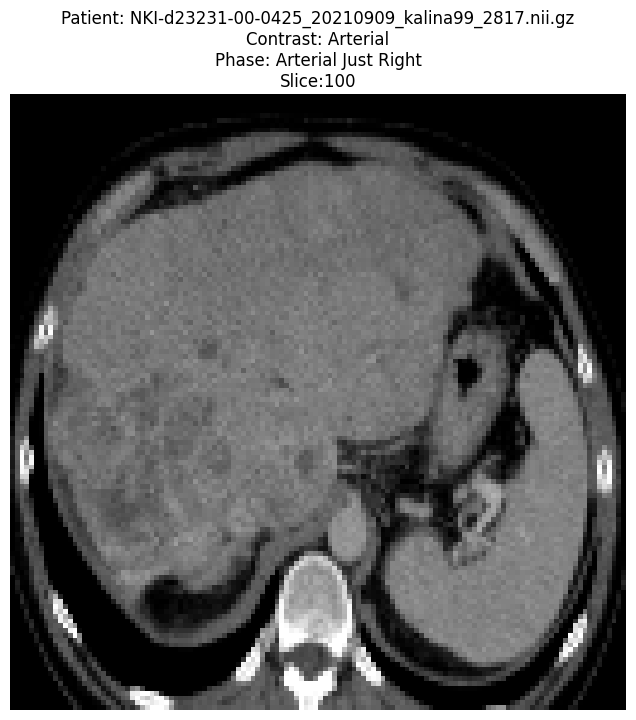

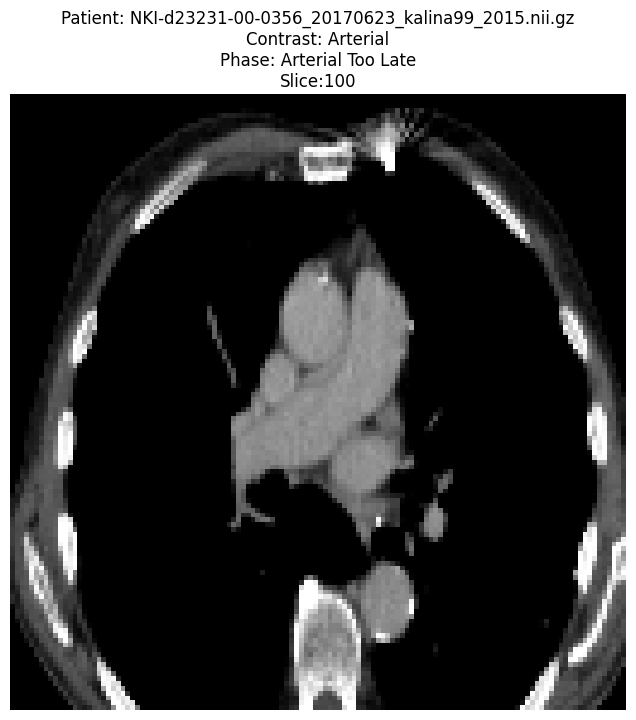

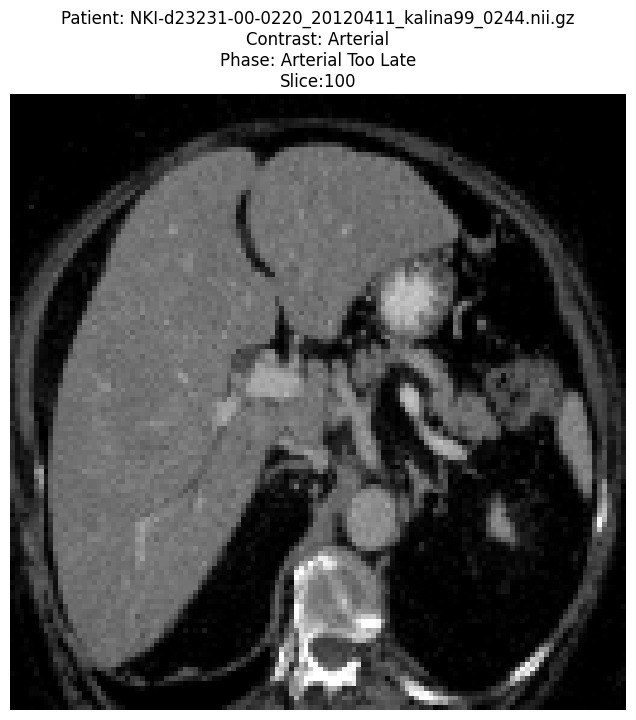

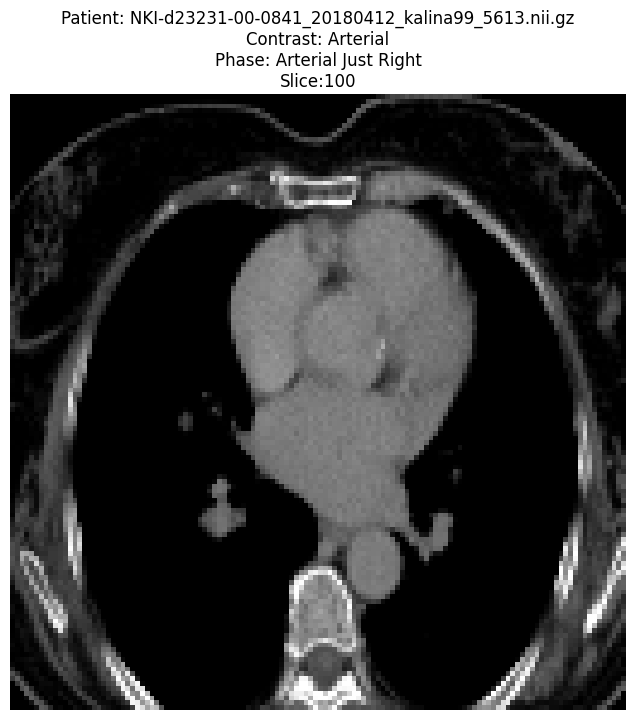

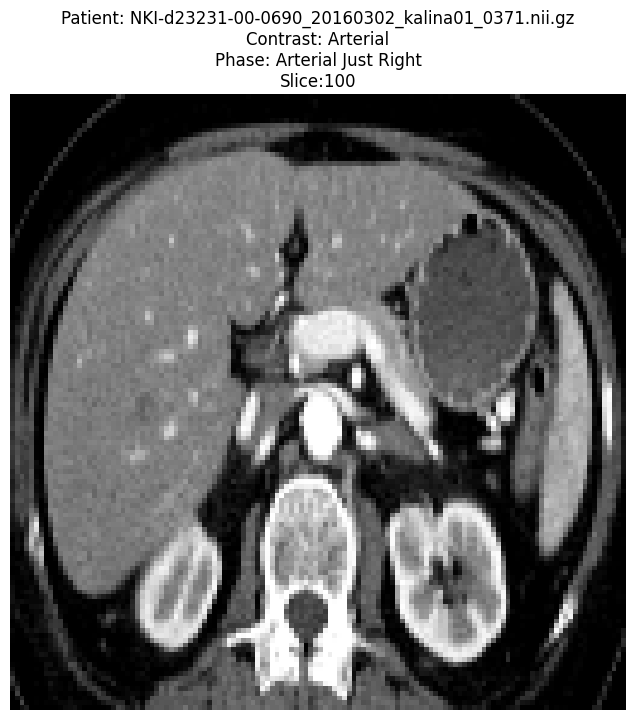

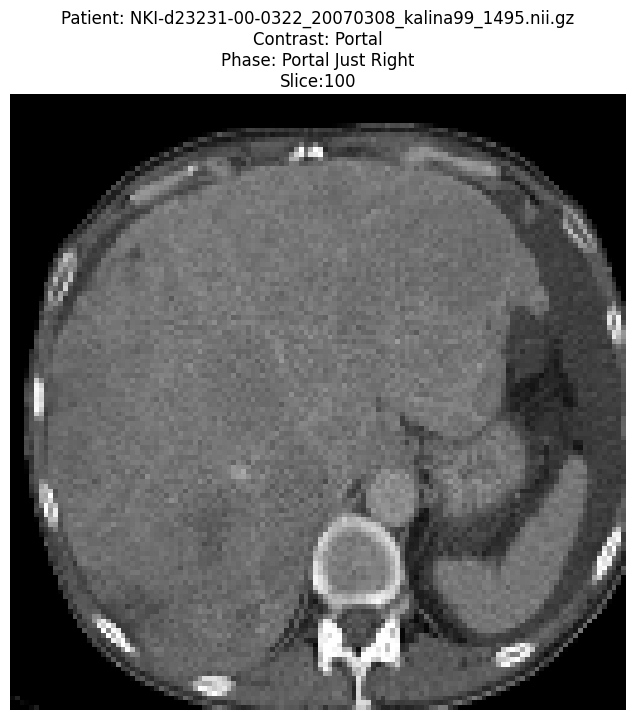

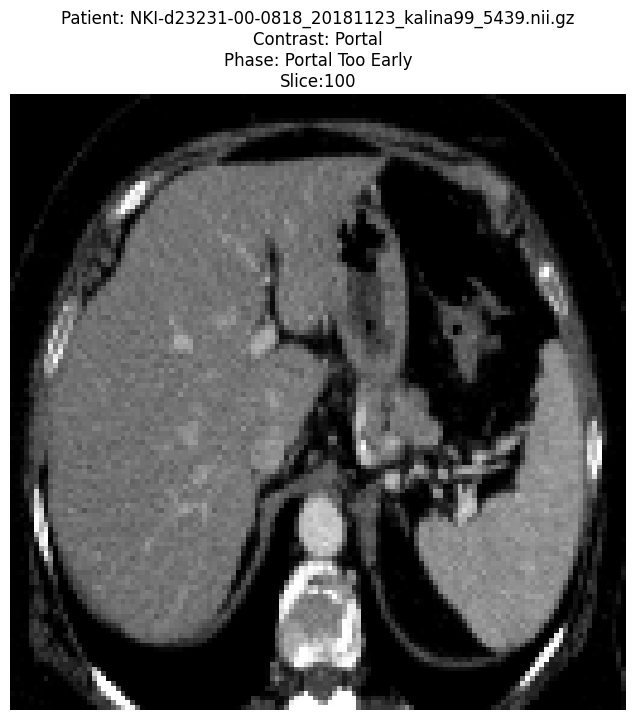

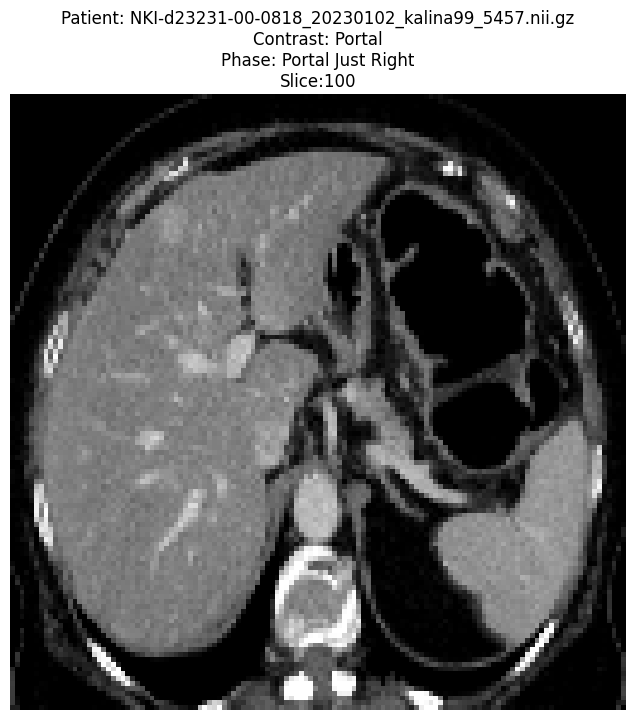

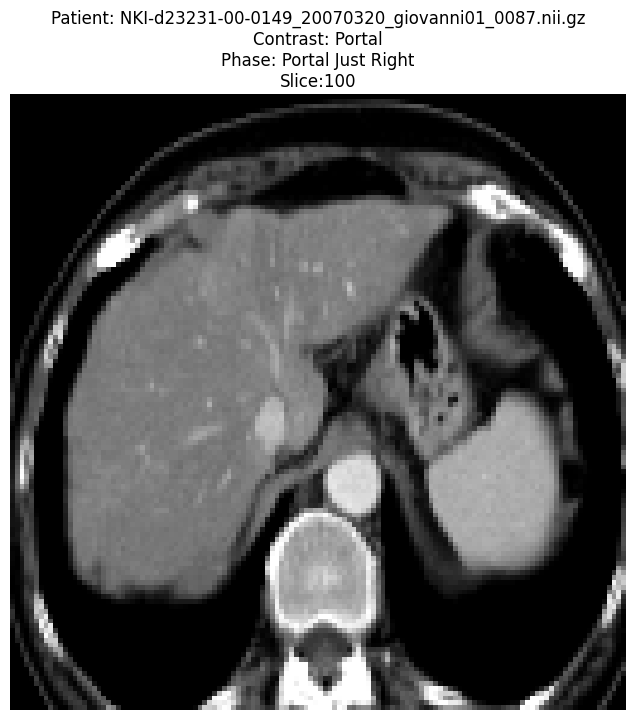

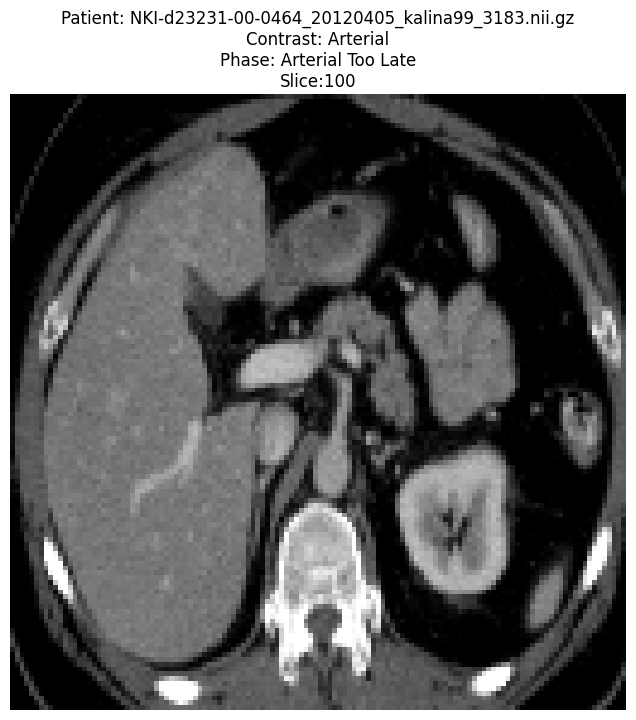

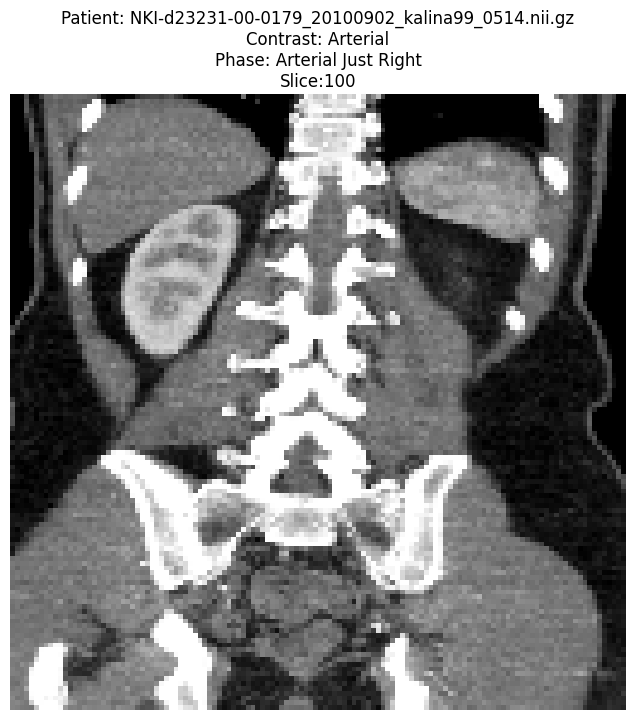

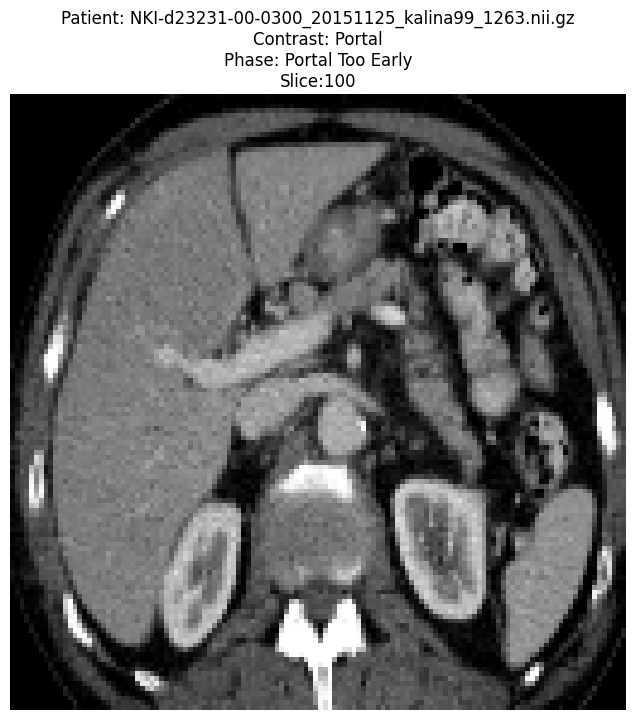

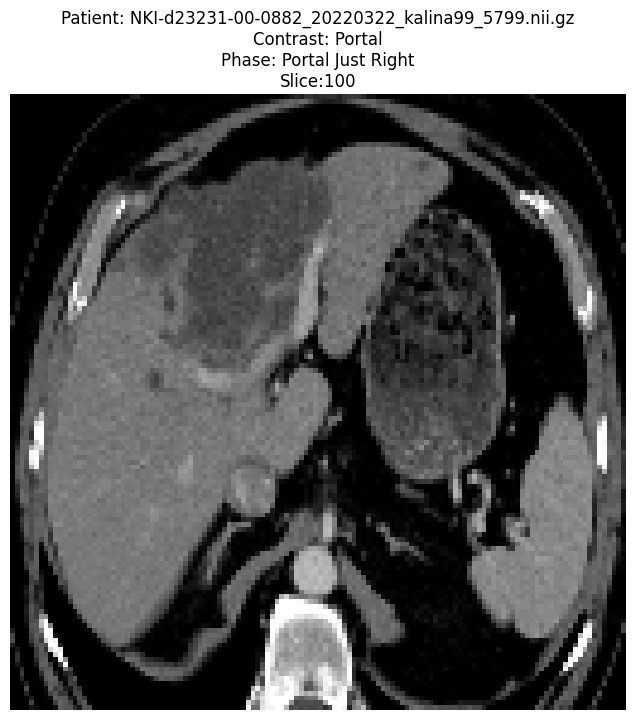

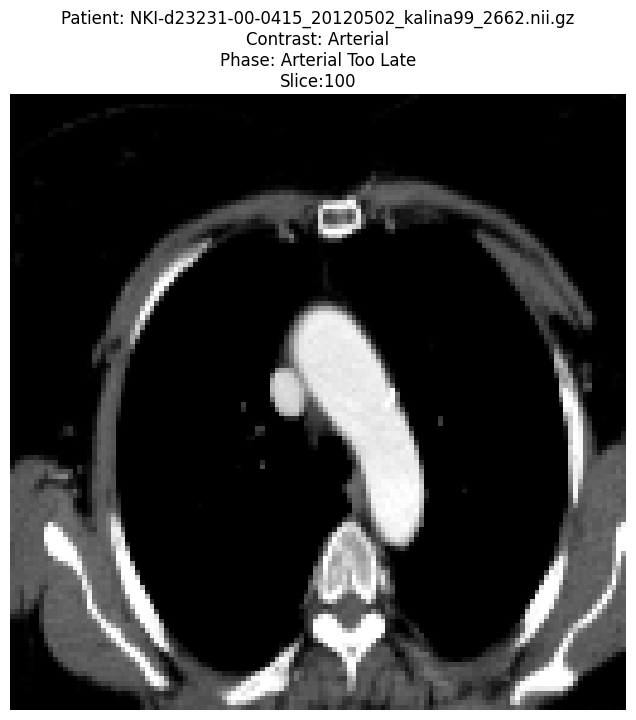

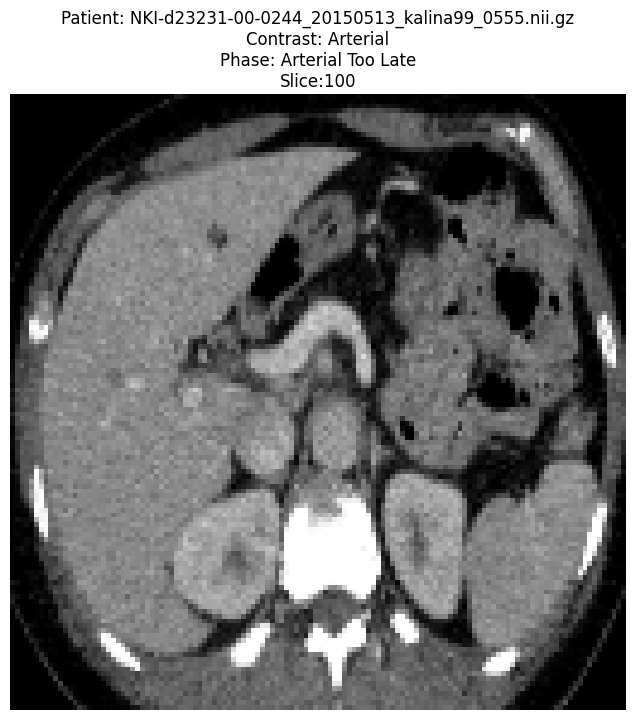

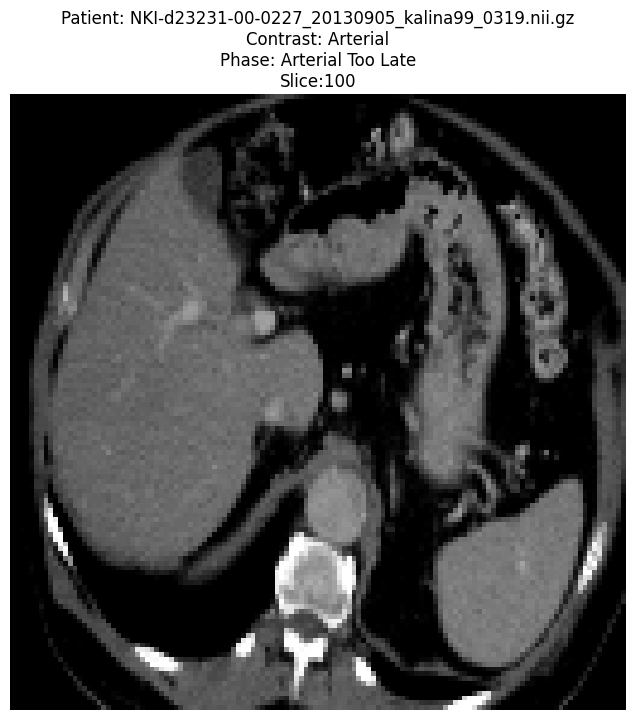

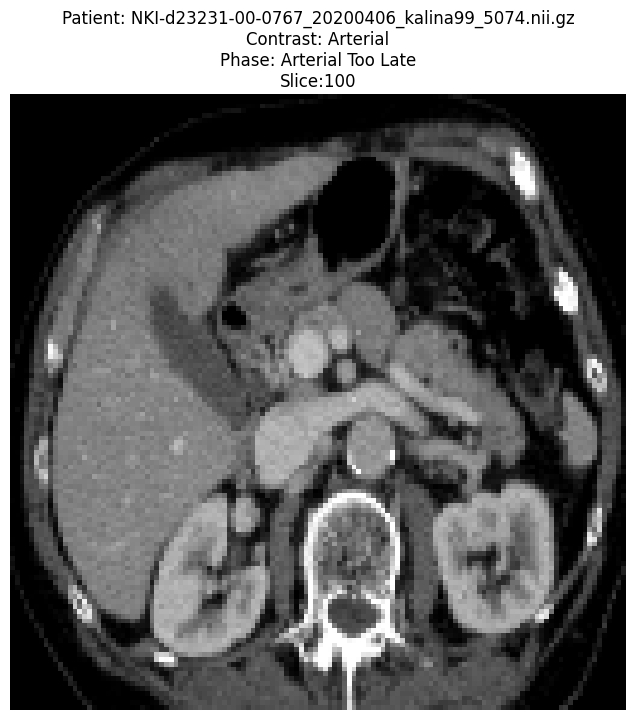

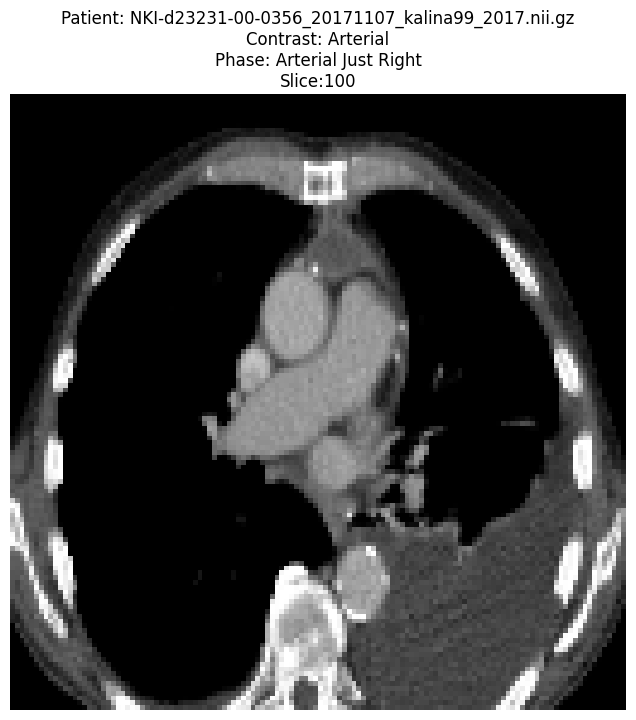

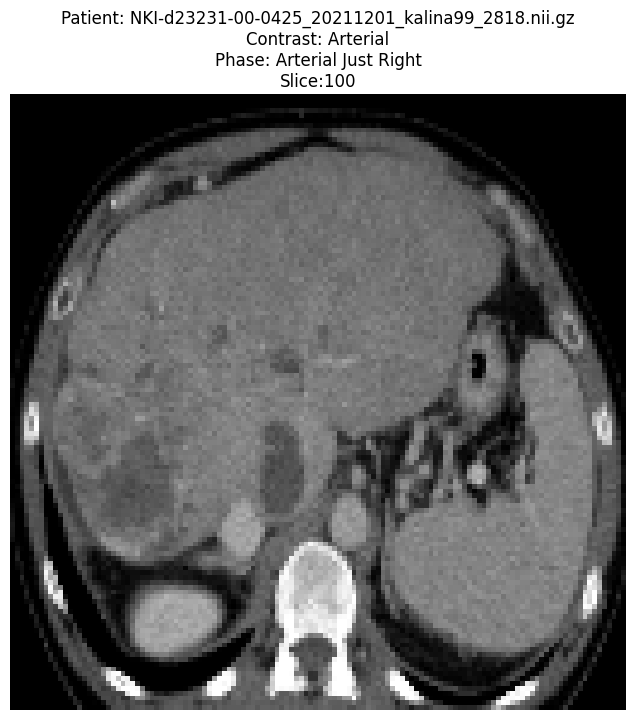

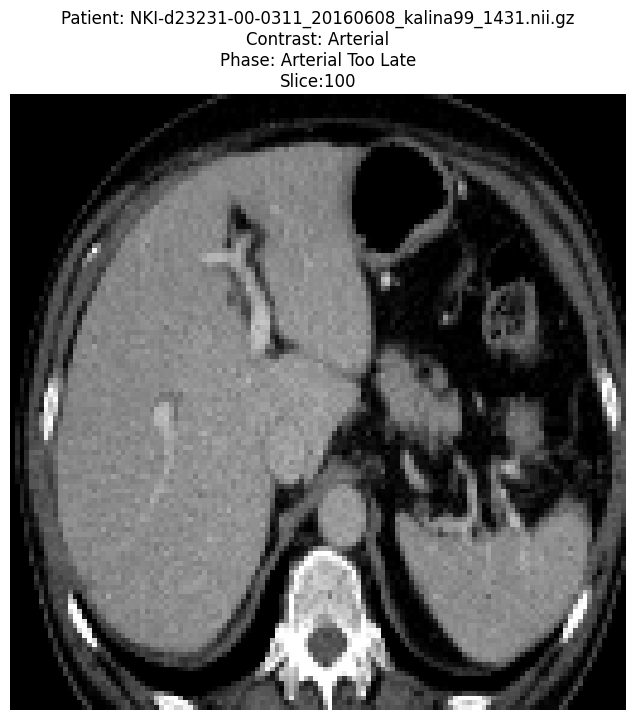

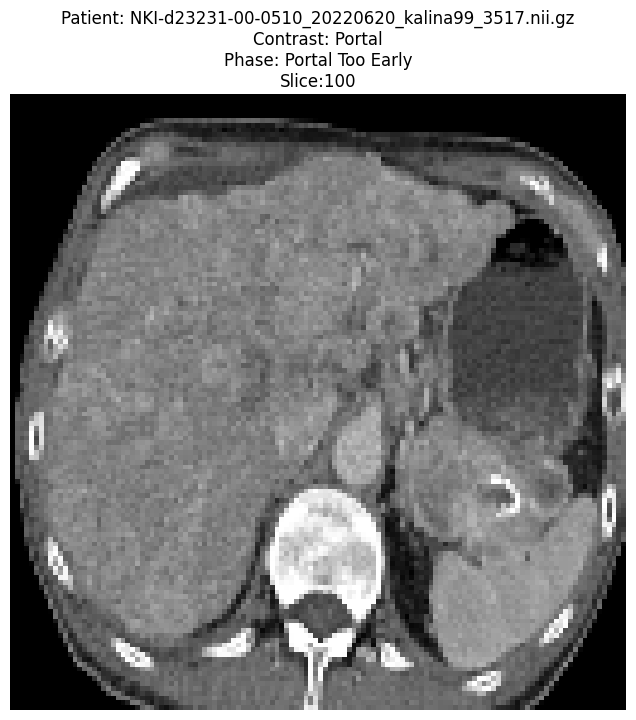

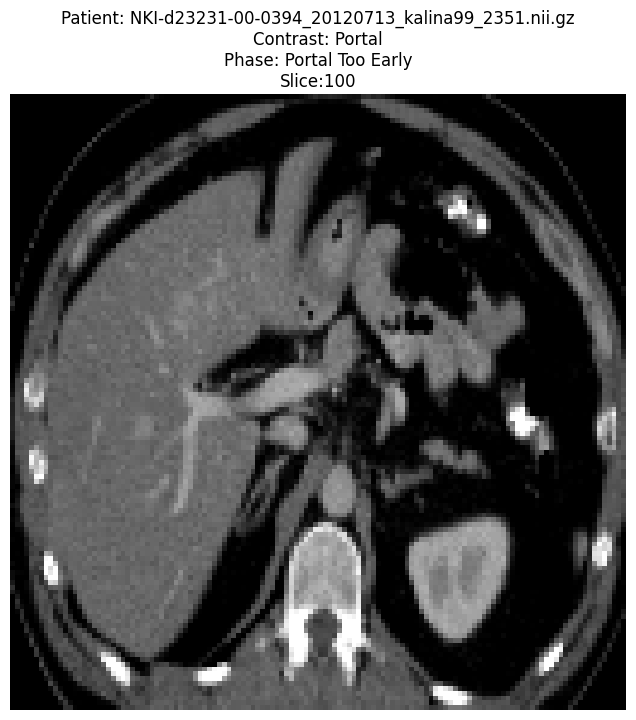

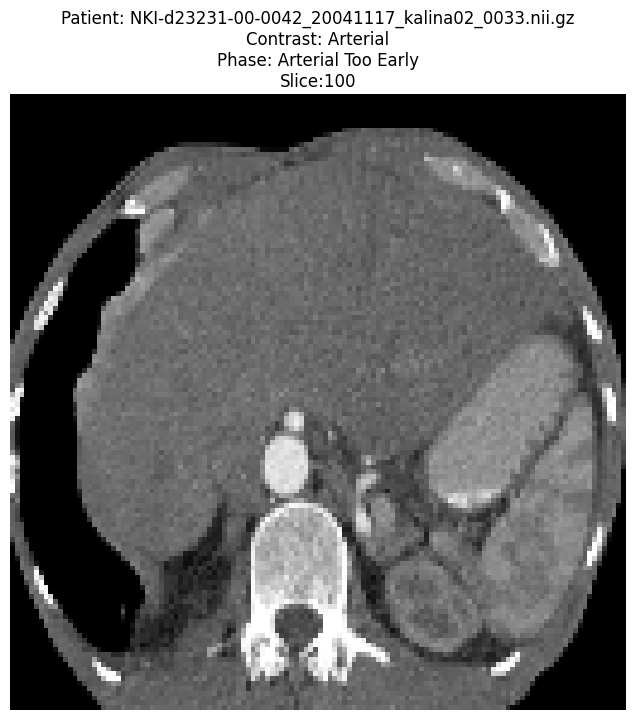

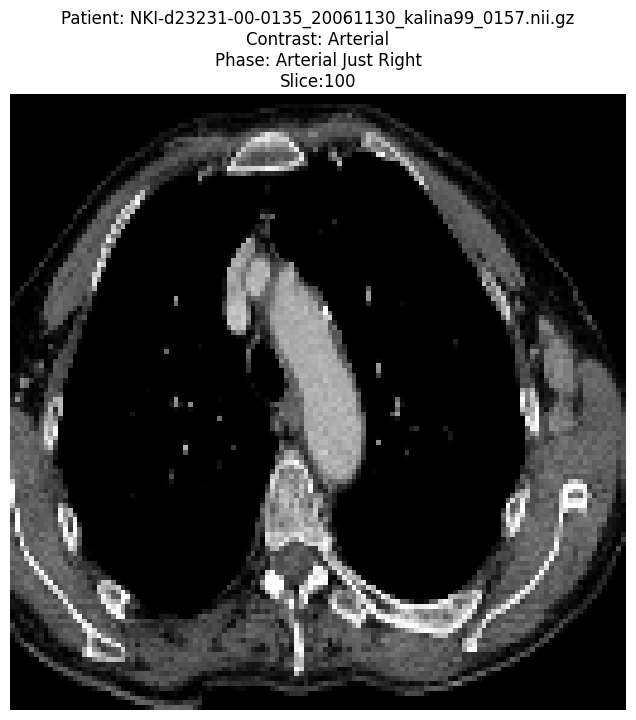

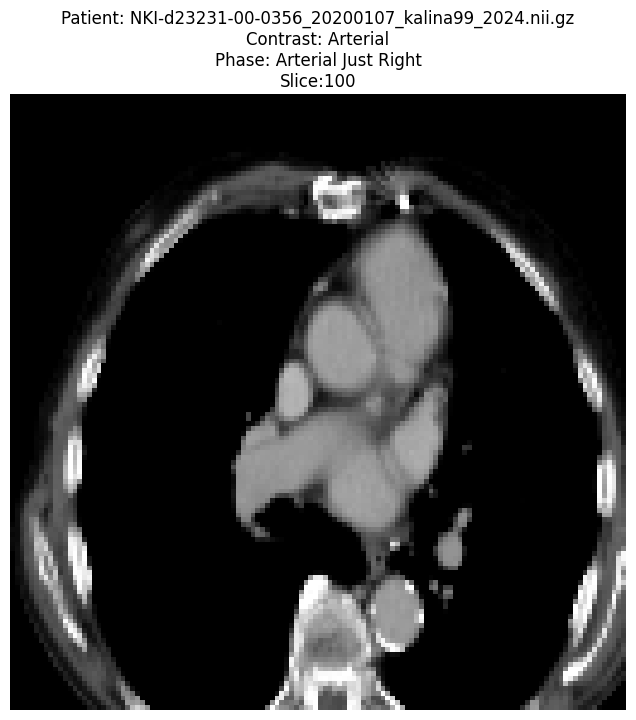

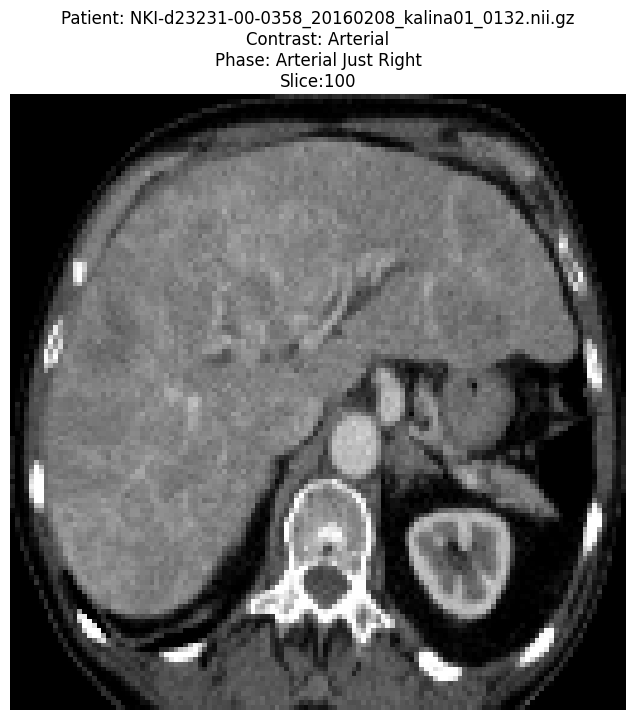

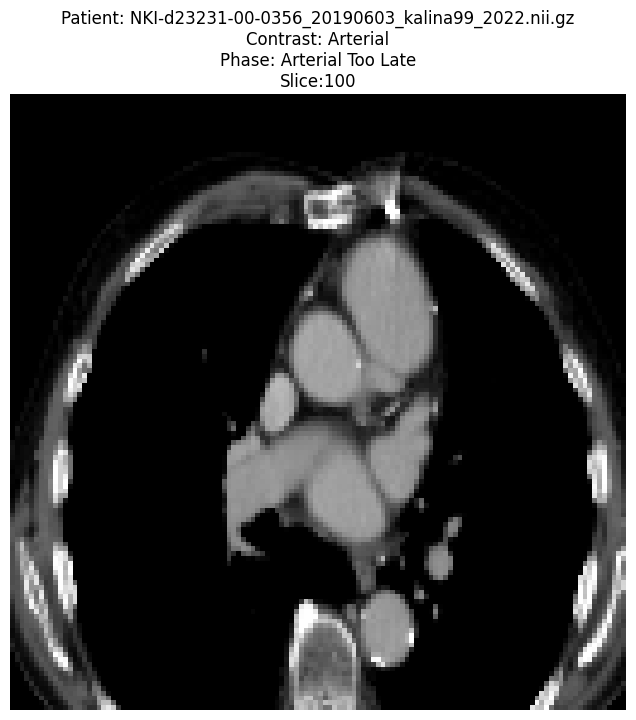

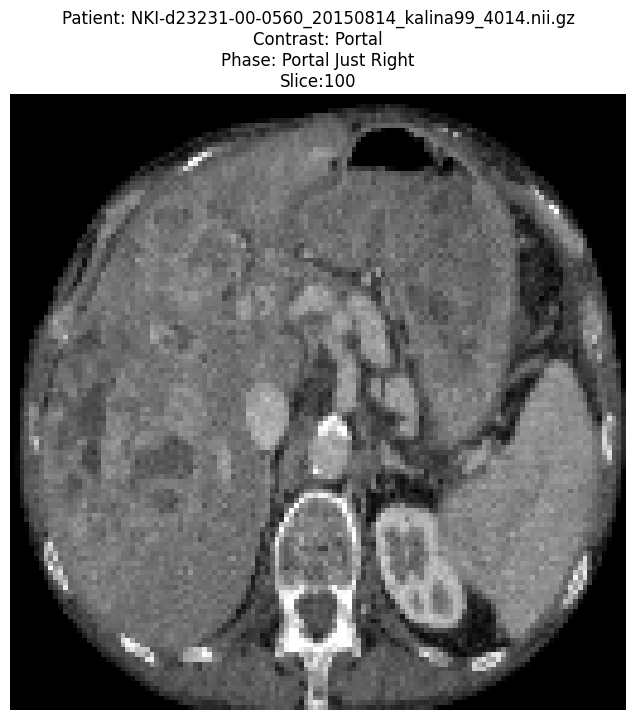

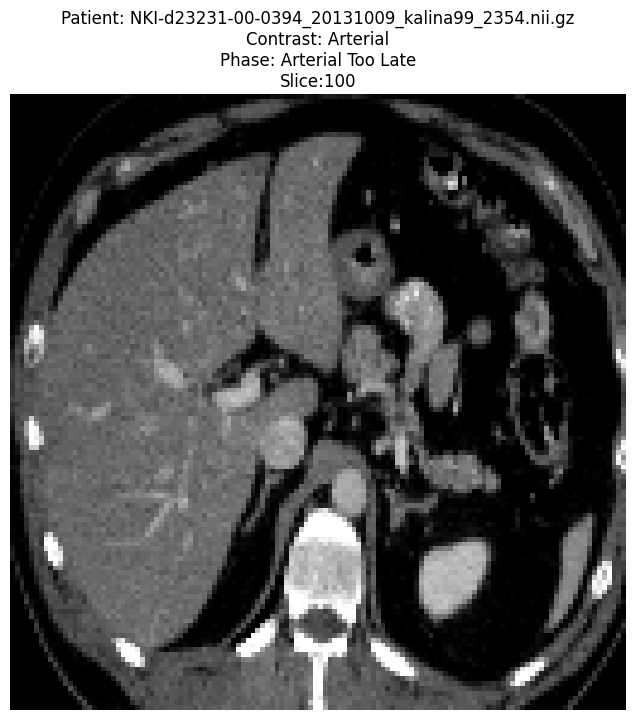

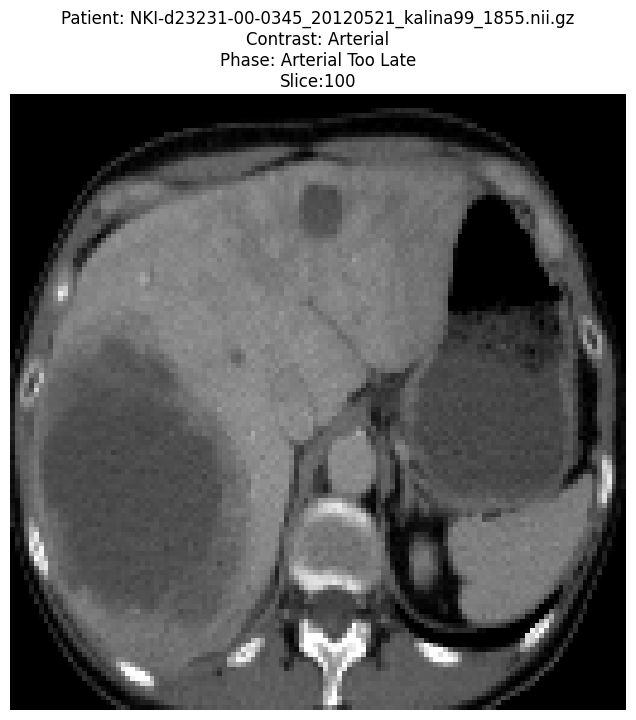

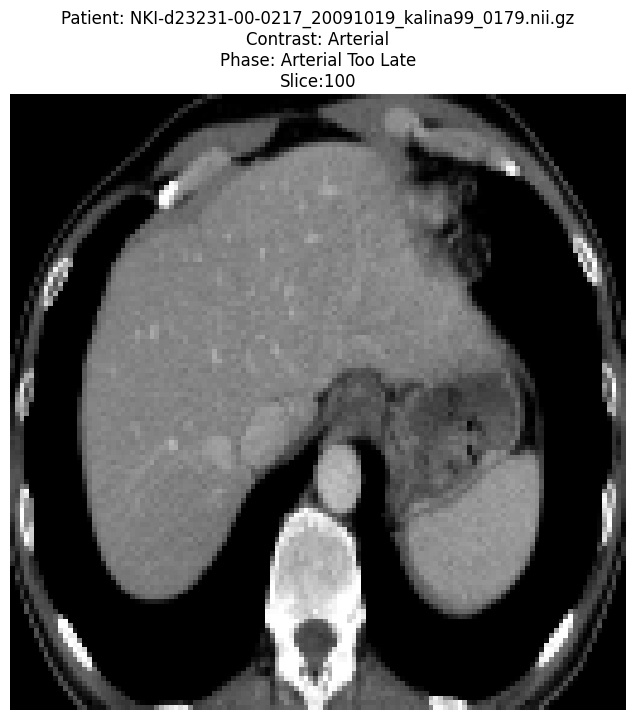

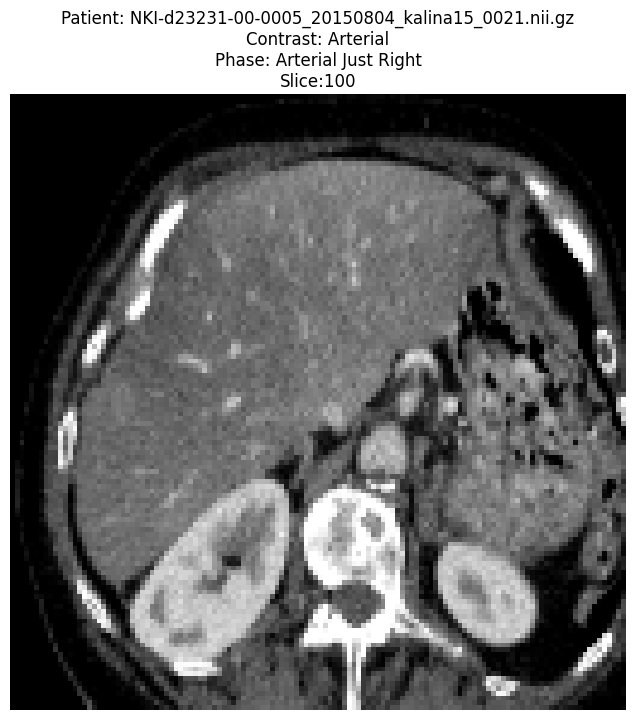

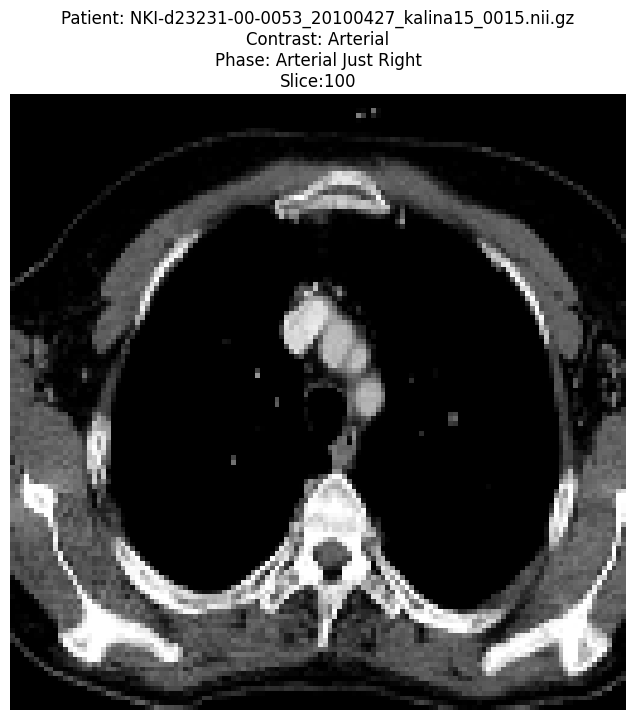

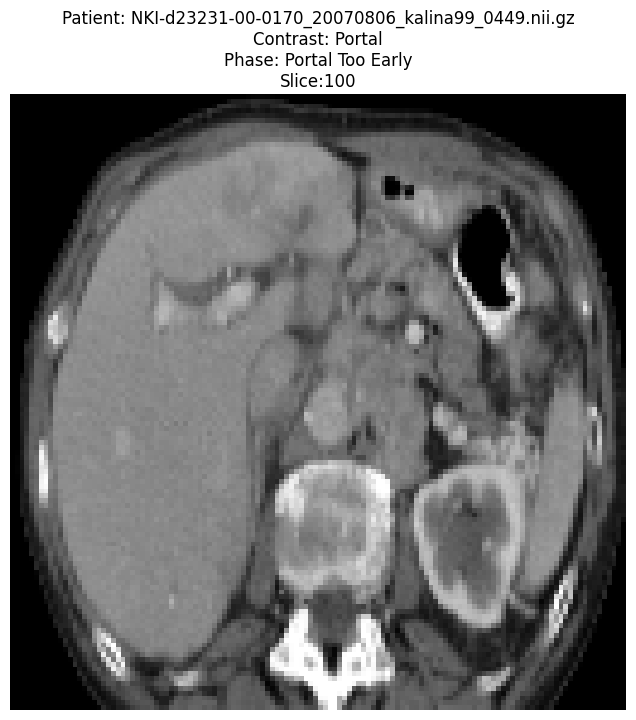

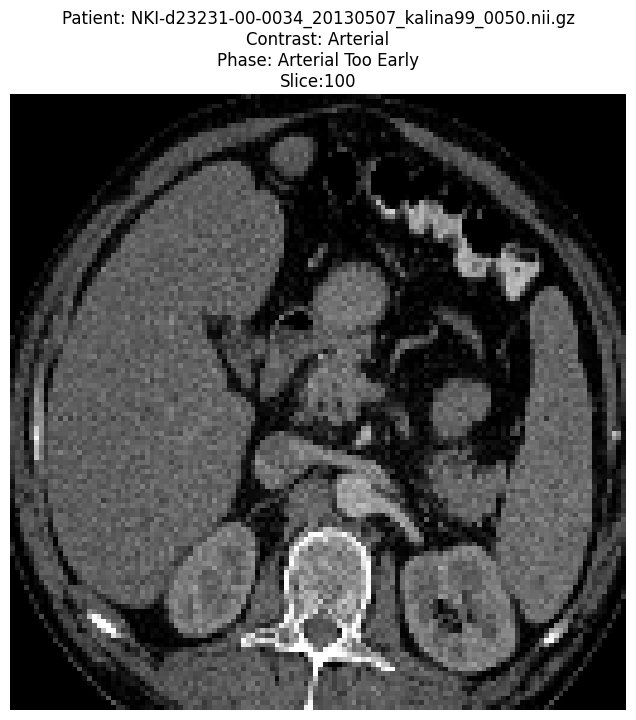

In [4]:

slice = 100
for i in range(len(misclass_data)):
    image = misclass_data[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {misclass_data[i][1]}\nContrast: {misclass_data[i][3]}\nPhase: {misclass_data[i][4]}\nSlice:{slice}")
    plt.axis("off")

In [4]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
data

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server
0,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,../DICOM-batch1\NKI-d23231-00-0063\20120416 CT...,DICOM-batch1-kalina01,NET_0000_0000.nii.gz,NKI-d23231-00-0063,2012-04-16,NET_0000_0000.nii.gz,Partially,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,40231.70000,Arterial,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
1,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,../DICOM-batch1\NKI-d23231-00-0070\20150821 CT...,DICOM-batch1-kalina01,NET_0001_0000.nii.gz,NKI-d23231-00-0070,2015-08-21,NET_0001_0000.nii.gz,Yes,Non-contrast,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,LEVER,NaN,1.0,30853.90000,Non-contrast,NKI-d23231-00-0070_20150821_kalina01_0001.nii.gz,NaN
2,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,../DICOM-batch1\NKI-d23231-00-0036\20140218 CT...,DICOM-batch1-kalina01,NET_0002_0000.nii.gz,NKI-d23231-00-0036,2014-02-18,NET_0002_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,32599.60000,NaN,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,../DICOM-batch1\NKI-d23231-00-0071\20130924 CT...,DICOM-batch1-kalina01,NET_0003_0000.nii.gz,NKI-d23231-00-0071,2013-09-24,NET_0003_0000.nii.gz,Yes,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,45013.30692,NaN,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,../DICOM-batch1\NKI-d23231-00-0077\20141222 CT...,DICOM-batch1-kalina01,NET_0004_0000.nii.gz,NKI-d23231-00-0077,2014-12-22,NET_0004_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,51587.10418,Portal,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8729,Z:\_archived\DICOM-batch3-kalina99\NET_5827_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5827_00...,../DICOM-batch3\NKI-d23231-00-0888\20220420 CT...,DICOM-batch3-kalina99,NET_5827_0000.nii.gz,NKI-d23231-00-0888,2022-04-20,NET_5827_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,54796.11932,Portal,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8730,Z:\_archived\DICOM-batch3-kalina99\NET_5828_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5828_00...,../DICOM-batch3\NKI-d23231-00-0888\20230424 CT...,DICOM-batch3-kalina99,NET_5828_0000.nii.gz,NKI-d23231-00-0888,2023-04-24,NET_5828_0000.nii.gz,Yes,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,43545.56100,Arterial,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8731,Z:\_archived\DICOM-batch3-kalina99\NET_5829_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5829_00...,../DICOM-batch3\NKI-d23231-00-0888\20230424 CT...,DICOM-batch3-kalina99,NET_5829_0000.nii.gz,NKI-d23231-00-0888,2023-04-24,NET_5829_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,43580.13800,NaN,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8732,Z:\_archived\DICOM-batch3-kalina99\NET_5830_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5830_00...,../DICOM-batch3\NK

In [5]:
merged = data.merge(results, left_on="MatchKey", right_on="key", how="inner")
merged

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server,key,true,pred
0,Z:\_archived\DICOM-batch1-kalina02\NET_0033_00...,Z:\_archived\DICOM-batch1-kalina02\NET_0033_00...,../DICOM-batch1\NKI-d23231-00-0042\20041117 Ab...,DICOM-batch1-kalina02,NET_0033_0000.nii.gz,NKI-d23231-00-0042,2004-11-17,NET_0033_0000.nii.gz,Partially,Arterial,...,ABDOMEN,NaN,1.5,33097.46003,Arterial,NKI-d23231-00-0042_20041117_kalina02_0033.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0042_20041117_kalina02_0033.nii.gz,Arterial,Non-contrast
1,Z:\_archived\DICOM-batch1-kalina15\NET_0015_00...,Z:\_archived\DICOM-batch1-kalina15\NET_0015_00...,../DICOM-batch1\NKI-d23231-00-0053\20100427 Ab...,DICOM-batch1-kalina15,NET_0015_0000.nii.gz,NKI-d23231-00-0053,2010-04-27,NET_0015_0000.nii.gz,Partially,Arterial,...,CHEST,NaN,1.5,56855.04478,NaN,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,NaN,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,Arterial,Portal
2,Z:\_archived\DICOM-batch1-kalina15\NET_0021_00...,Z:\_archived\DICOM-batch1-kalina15\NET_0021_00...,../DICOM-batch1\NKI-d23231-00-0005\20150804 CT...,DICOM-batch1-kalina15,NET_0021_0000.nii.gz,NKI-d23231-00-0005,2015-08-04,NET_0021_0000.nii.gz,Yes,Arterial,...,ABDOMEN,NaN,1.0,43830.95000,NaN,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,Arterial,Portal
3,Z:\_archived\DICOM-batch1-kalina99\NET_0050_00...,Z:\_archived\DICOM-batch1-kalina99\NET_0050_00...,../DICOM-batch1\NKI-d23231-00-0034\20130507 CT...,DICOM-batch1-kalina99,NET_0050_0000.nii.gz,NKI-d23231-00-0034,2013-05-07,NET_0050_0000.nii.gz,Partially,Arterial,...,ABDOMEN,NaN,1.5,60125.10458,Arterial,NKI-d23231-00-0034_20130507_kalina99_0050.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0034_20130507_kalina99_0050.nii.gz,Arterial,Portal
4,Z:\_archived\DICOM-batch2-giovanni01\NET_0087_...,Z:\_archived\DICOM-batch2-giovanni01\NET_0087_...,../DICOM-batch2\NKI-d23231-00-0149\20070320 Ab...,DICOM-batch2-giovanni01,NET_0087_0000.nii.gz,NKI-d23231-00-0149,2007-03-20,NET_0087_0000.nii.gz,Yes,Portal,...,ABDOMEN,NaN,3.0,46647.83980,Portal,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,Portal,Arterial
5,Z:\_archived\DICOM-batch2-kalina99\NET_0157_00...,Z:\_archived\DICOM-batch2-kalina99\NET_0157_00...,../DICOM-batch2\NKI-d23231-00-0135\20061130 Ab...,DICOM-batch2-kalina99,NET_0157_0000.nii.gz,NKI-d23231-00-0135,2006-11-30,NET_0157_0000.nii.gz,Partially,Arterial,...,CHEST,NaN,1.5,52369.95988,NaN,NKI-d23231-00-0135_20061130_kalina99_0157.nii.gz,NaN,NKI-d23231-00-0135_20061130_kalina99_0157.nii.gz,Arterial,Portal
6,Z:\_archived\DICOM-batch2-kalina99\NET_0449_00...,Z:\_archived\DICOM-batch2-kalina99\NET_0449_00...,../DICOM-batch2\NKI-d23231-00-0170\20070806 CT...,DICOM-batch2-kalina99,NET_0449_0000.nii.gz,NKI-d23231-00-0170,2007-08-06,NET_0449_0000.nii.gz,Yes,Portal,...,ABDOMEN,NaN,2.0,54404.00000,Portal,NKI-d23231-00-0170_20070806_kalina99_0449.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0170_20070806_kalina99_0449.nii.gz,Portal,Arterial
7,Z:\_archived\DICOM-batch2-kalina99\NET_0514_00...,Z:\_archived\DICOM-batch2-kalina99\NET_0514_00...,../DICOM-batch2\NKI-d23231-00-0179\20100902 CT...,DICOM-batch2-kalina99,NET_0514_0000.nii.gz,NKI-d23231-00-0179,2010-09-02,NET_0514_0000.nii.gz,Yes,Arterial,...,NaN,False,3.0,39862.00000,NaN,NKI-d23231-00-0179_20100902_kalina99_0514.nii.gz,NaN,NKI-d23231-00-0179_20100902_kalina99_0514.nii.gz,Arterial,Portal
8,Z:\_archived\DICOM-batch3-kalina01\NET_0132_00...,Z:\_archived\DICOM-batch3-kalina01\NET_0132_00...,../DICOM-batch3\NKI-d23231-00-0358\20160208 CT...,DICOM-batch3-kalina01,NET_0132_0000.n

In [6]:
merged[["MatchKey", "NiiFile", "BodyPartExamined", "ProtocolName", "is_liver_imaged", "is_lesionfree", "metal_artifacts", "true", "pred"]]

,MatchKey,NiiFile,BodyPartExamined,ProtocolName,is_liver_imaged,is_lesionfree,metal_artifacts,true,pred
0,NKI-d23231-00-0042_20041117_kalina02_0033.nii.gz,Z:\_archived\DICOM-batch1-kalina02\NET_0033_00...,ABDOMEN,Lever A 1.5 B25f,Partially,No,False,Arterial,Non-contrast
1,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,Z:\_archived\DICOM-batch1-kalina15\NET_0015_00...,CHEST,Thorax 1.5 B45f,Partially,Yes,False,Arterial,Portal
2,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,Z:\_archived\DICOM-batch1-kalina15\NET_0021_00...,ABDOMEN,ABDOMEN + C 1.0 FC01,Yes,Yes,False,Arterial,Portal
3,NKI-d23231-00-0034_20130507_kalina99_0050.nii.gz,Z:\_archived\DICOM-batch1-kalina99\NET_0050_00...,ABDOMEN,Abdomen A 1.5 B25f,Partially,Yes,False,Arterial,Portal
4,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,Z:\_archived\DICOM-batch2-giovanni01\NET_0087_...,ABDOMEN,Venous Phase 3.0 B25f,Yes,No,False,Portal,Arterial
5,NKI-d23231-00-0135_20061130_kalina99_0157.nii.gz,Z:\_archived\DICOM-batch2-kalina99\NET_0157_00...,CHEST,Thorax 1.5 B45f,Partially,No,False,Arterial,Portal
6,NKI-d23231-00-0170_20070806_kalina99_0449.nii.gz,Z:\_archived\DICOM-batch2-kalina99\NET_0449_00...,ABDOMEN,Abdomen V 2mm,Yes,No,False,Portal,Arterial
7,NKI-d23231-00-0179_20100902_kalina99_0514.nii.gz,Z:\_archived\DICOM-batch2-kalina99\NET_0514_00...,NaN,COR 3MM,Yes,No,False,Arterial,Portal
8,NKI-d23231-00-0358_20160208_kalina01_0132.nii.gz,Z:\_archived\DICOM-batch3-kalina01\NET_0132_00...,ABDOMEN,ABDOMEN + C 1.0 FC01,Yes,No,False,Arterial,Portal
9,NKI-d23231-00-0690_20160302_kalina01_0371.nii.gz,Z:\_archived\DICOM-batch3-kalina01\NET_0371_00...,ABDOMEN,Abdo-Arterieel 3.0 B40f,Partially,Yes,False,Arterial,Portal


In [7]:
print(f"Images with lesions: {len(merged[merged.is_lesionfree == "No"])}")
print(f"Images with partially visible liver: {len(merged[merged.is_liver_imaged == "Partially"])}")
print(f"Images where \"BodyPartExamined\" is not \"ABDOMEN\": {len(merged[merged.BodyPartExamined != "ABDOMEN"])}")


Images with lesions: 26
Images with partially visible liver: 5
Images where "BodyPartExamined" is not "ABDOMEN": 6


In [8]:
with_lesions = merged[merged.is_lesionfree == "No"]
partial_liver = merged[merged.is_liver_imaged == "Partially"]
not_abd = merged[merged.BodyPartExamined != "ABDOMEN"]

In [9]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_preprocessed/test"

def show_misclass(folder, misclass_keys):
    dataset = []

    for f in os.listdir(folder):
        if not f.endswith(".pt"):
            continue

        base_name = os.path.splitext(f)[0]

        if any(base_name in k for k in misclass_keys):
            data = torch.load(os.path.join(folder, f))
            dataset.append((
                data['patient_id'],
                data['key'],
                data["image"],
                data["contrast"],
                data['phase']
            ))

    return dataset

In [10]:
with_lesions_images = show_misclass(folder, with_lesions["key"])

/tmp/ipykernel_742501/3868426600.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


/tmp/ipykernel_742501/627537808.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,8))


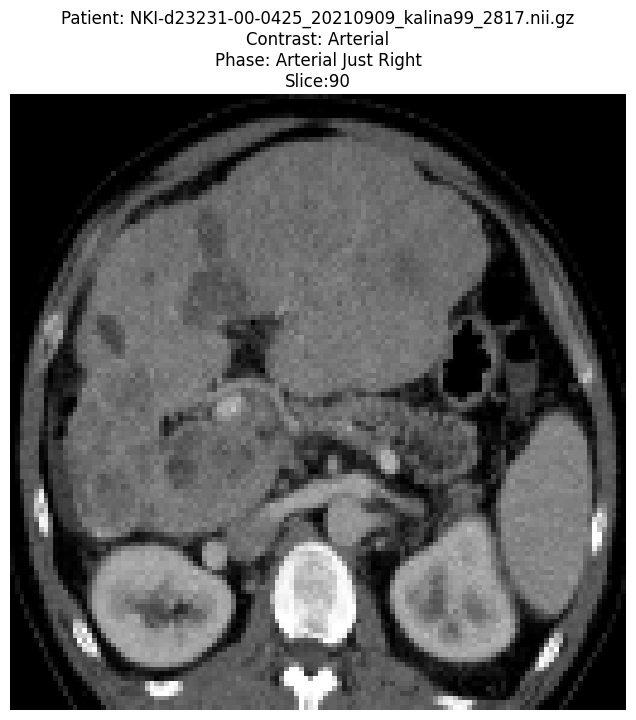

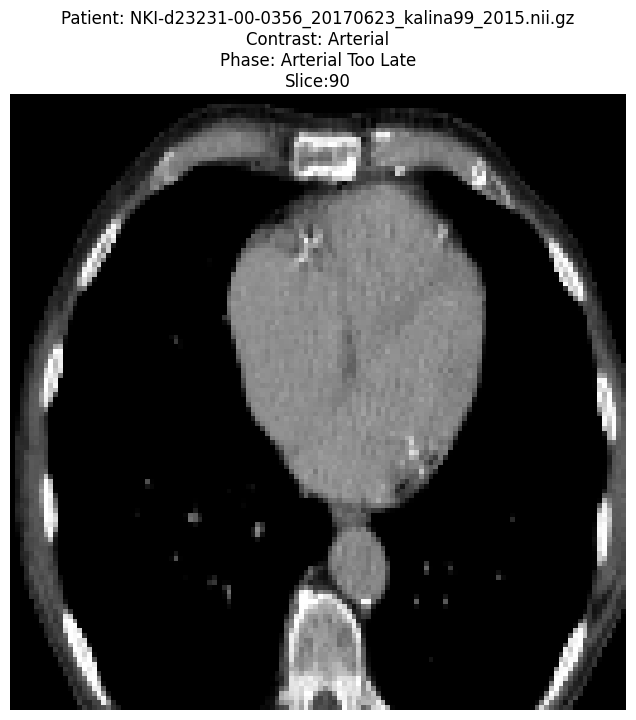

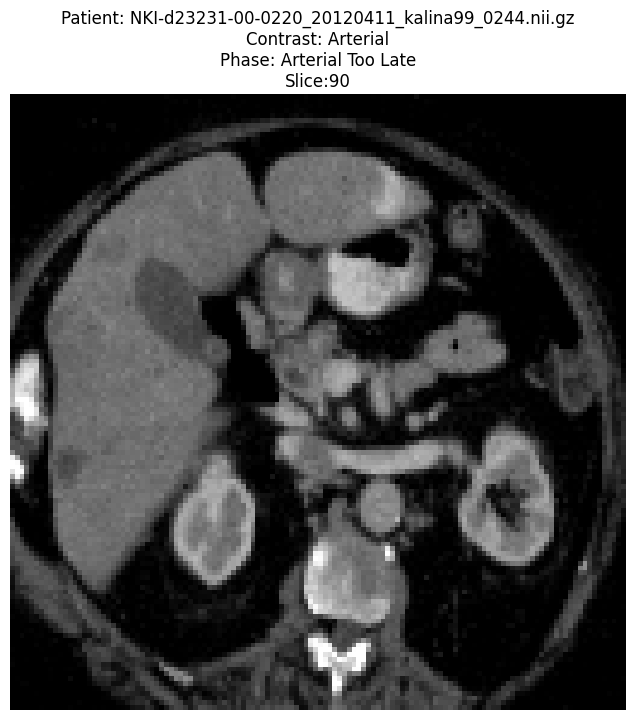

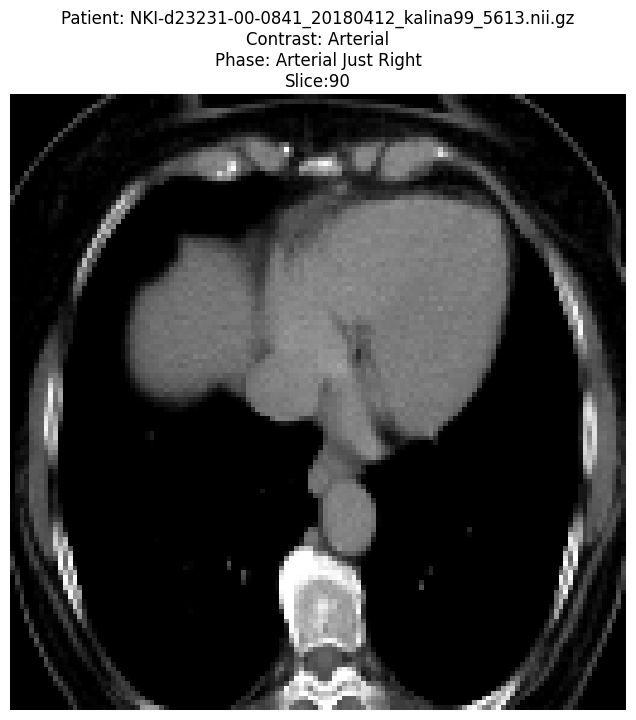

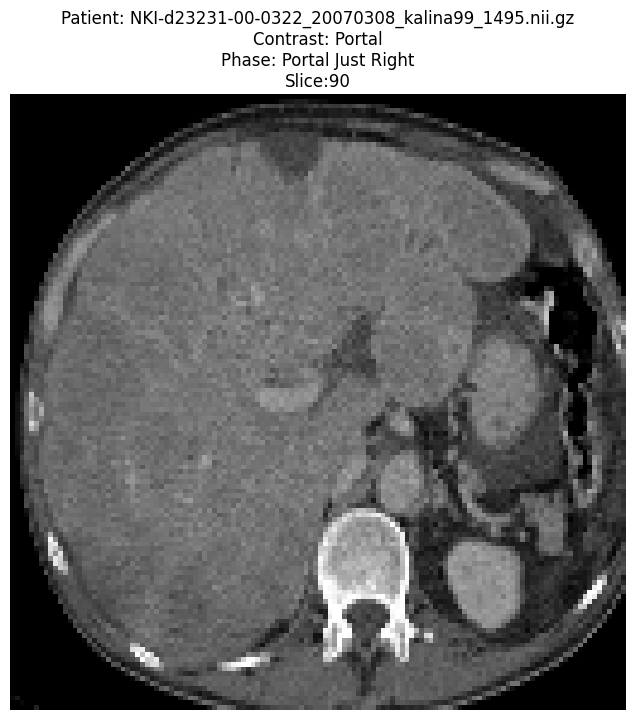

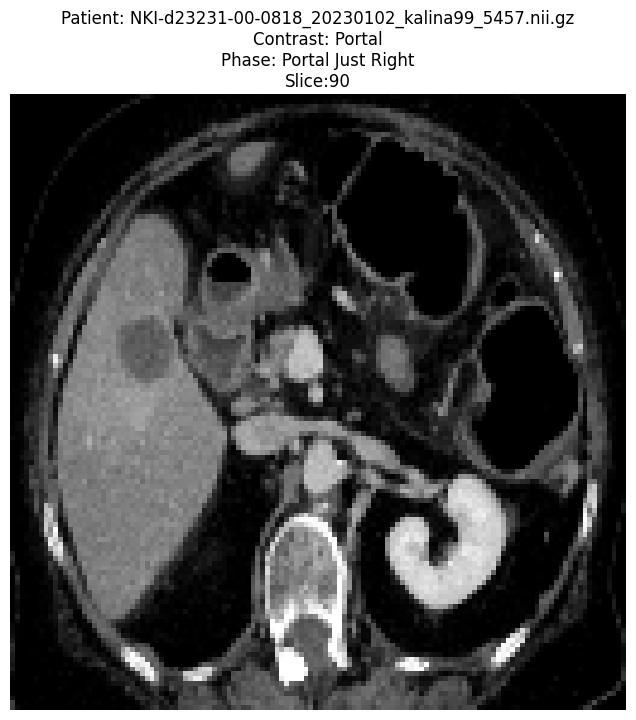

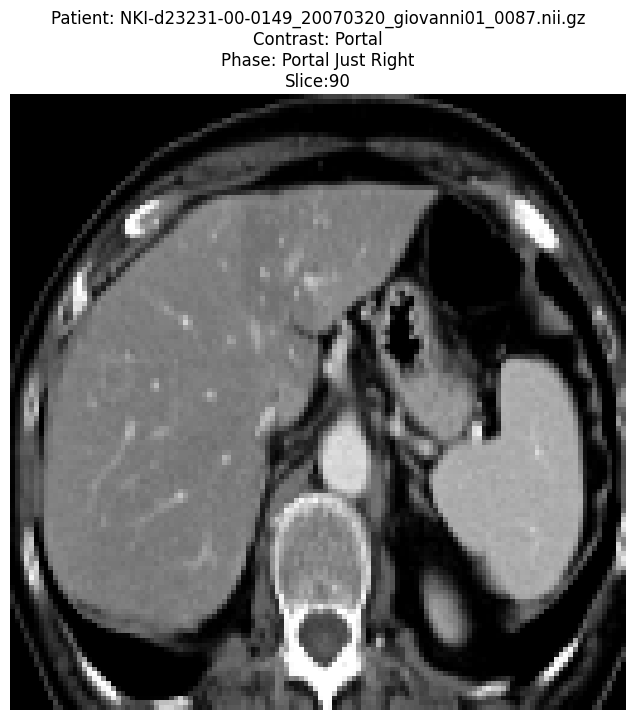

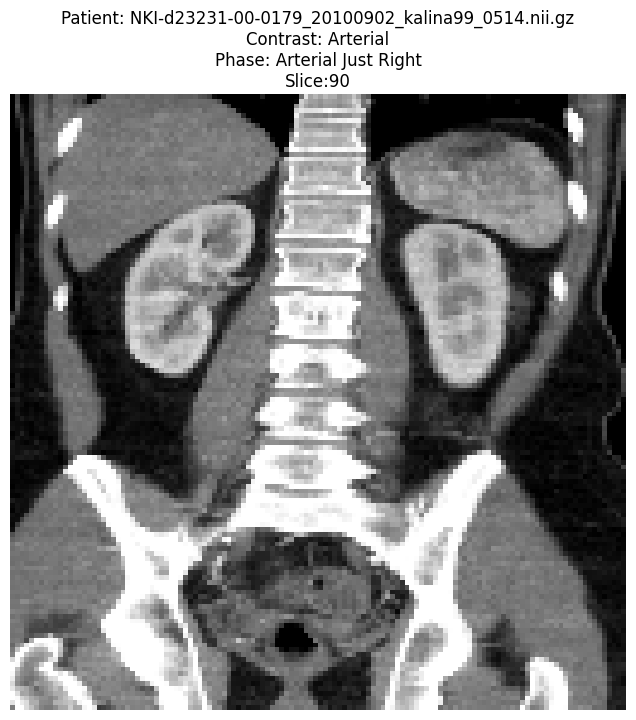

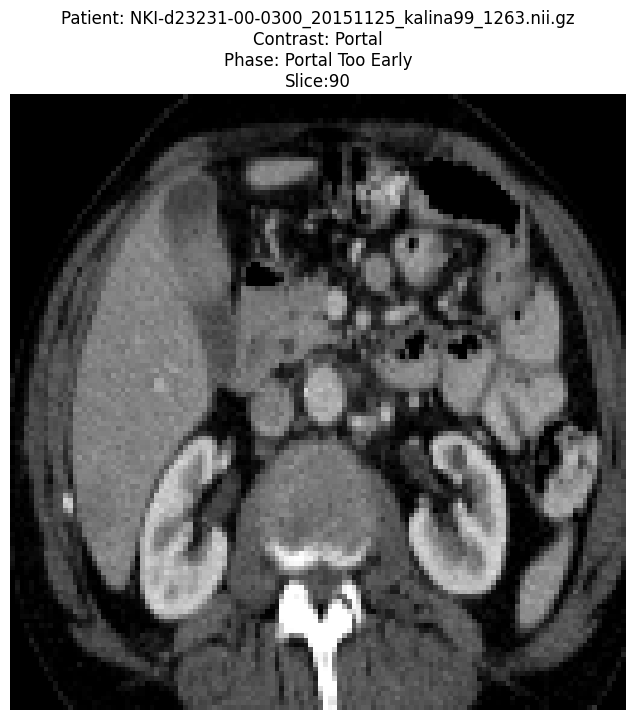

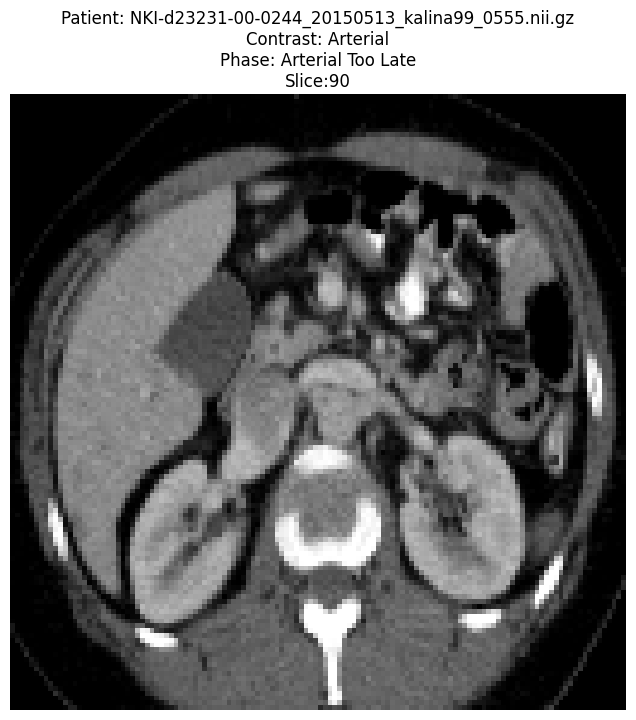

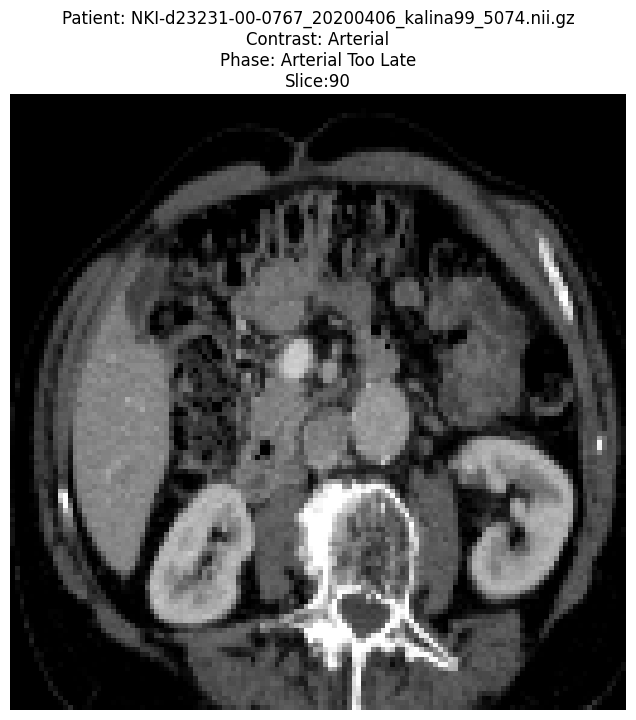

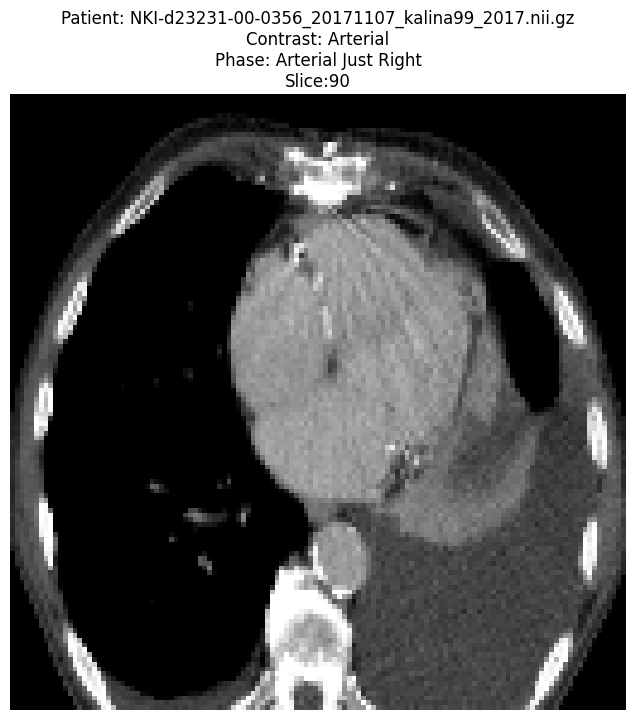

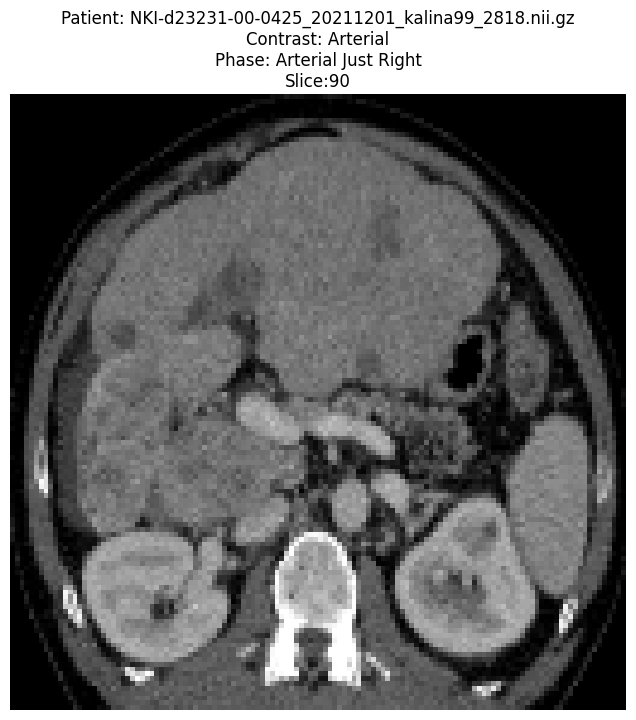

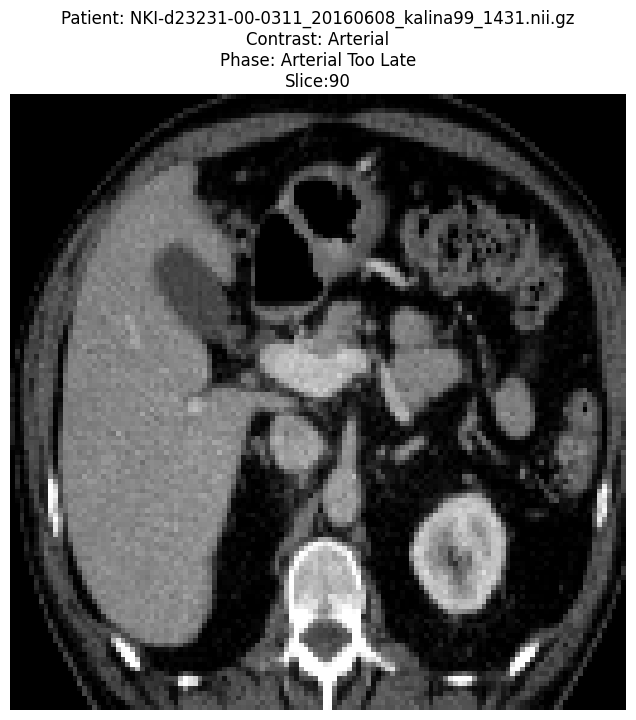

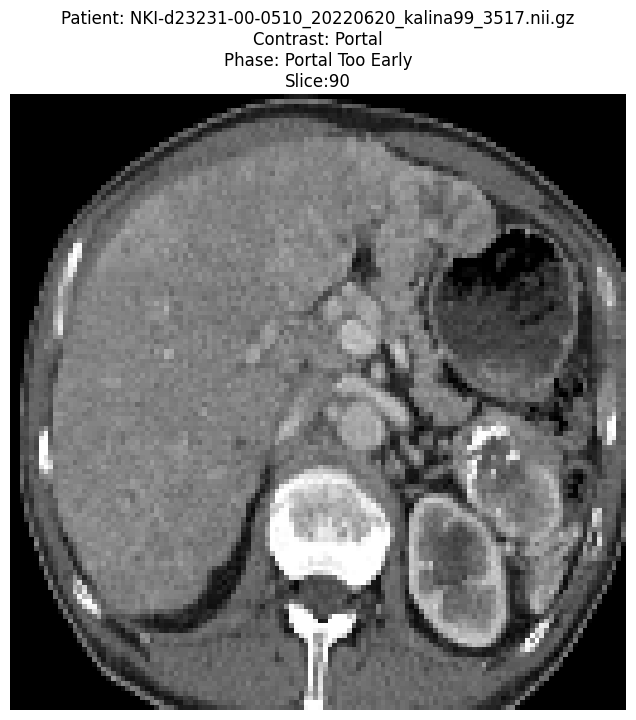

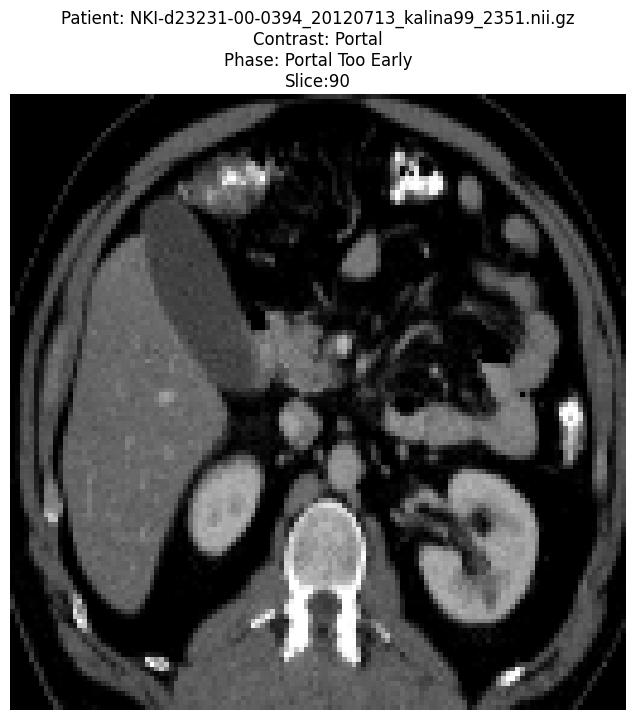

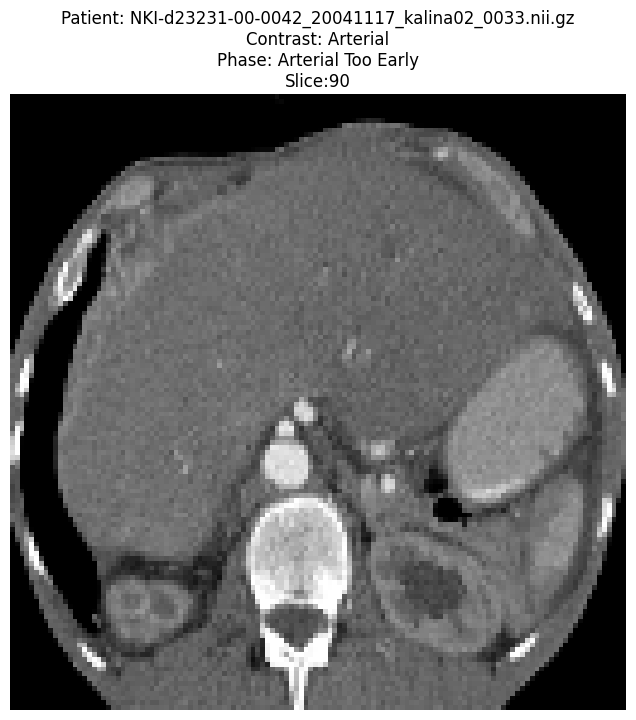

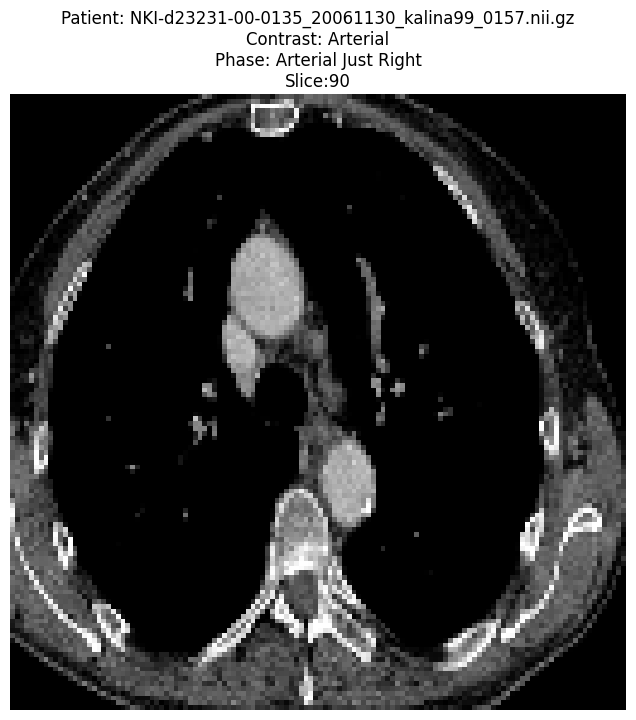

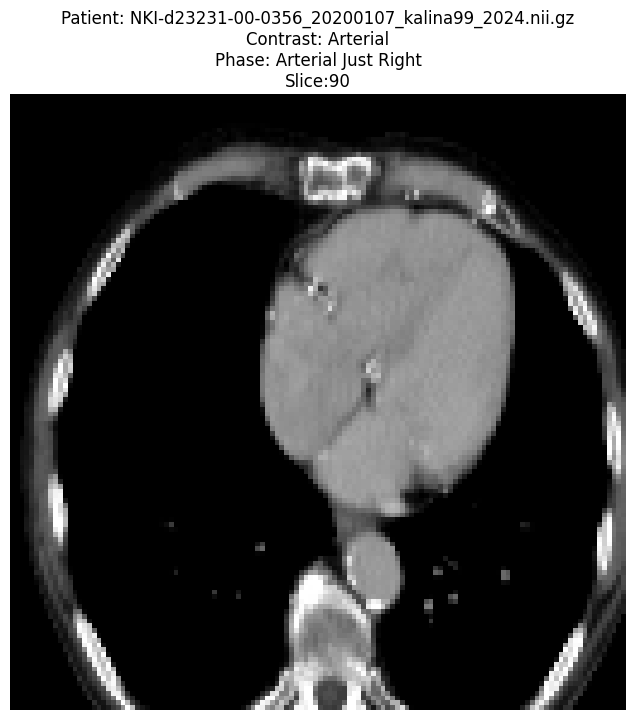

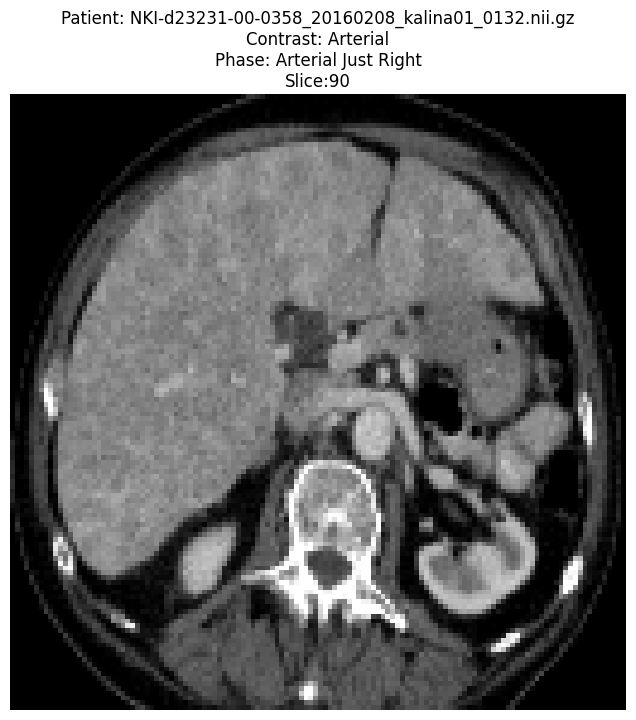

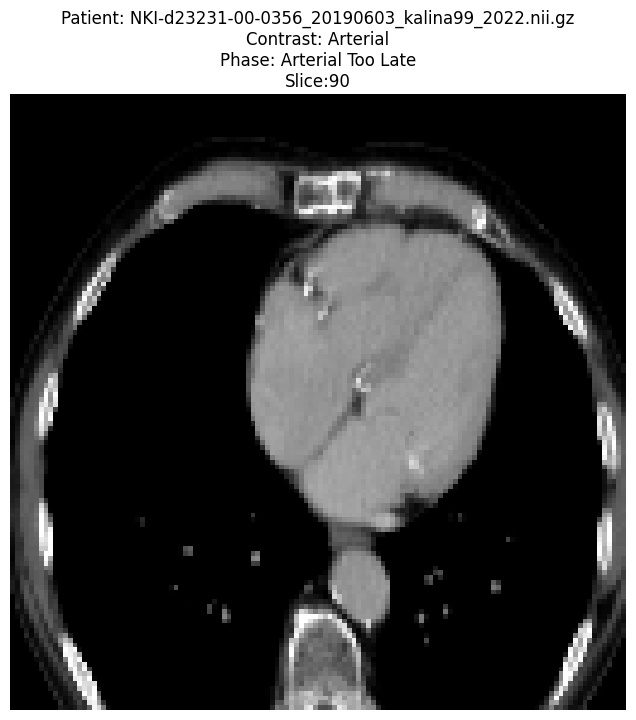

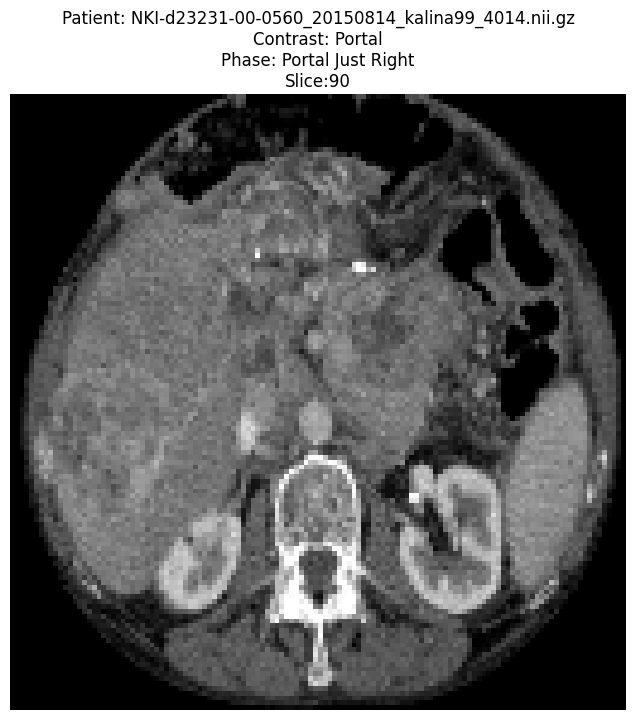

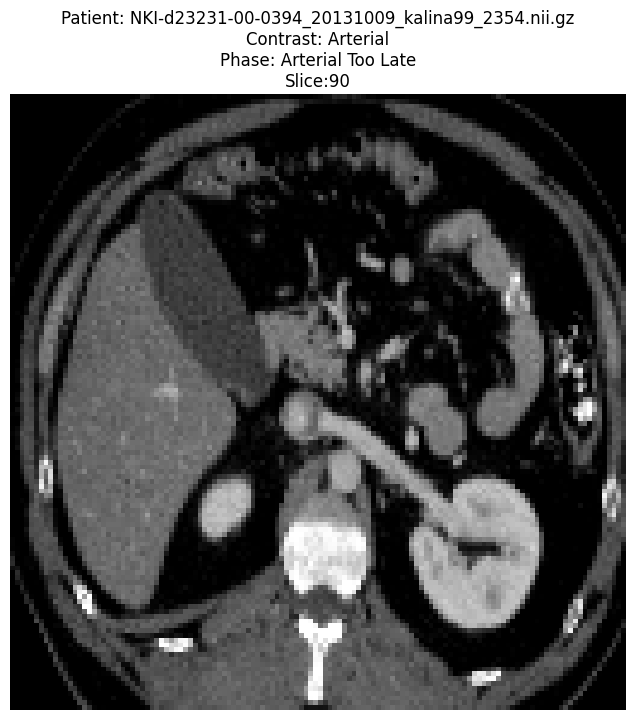

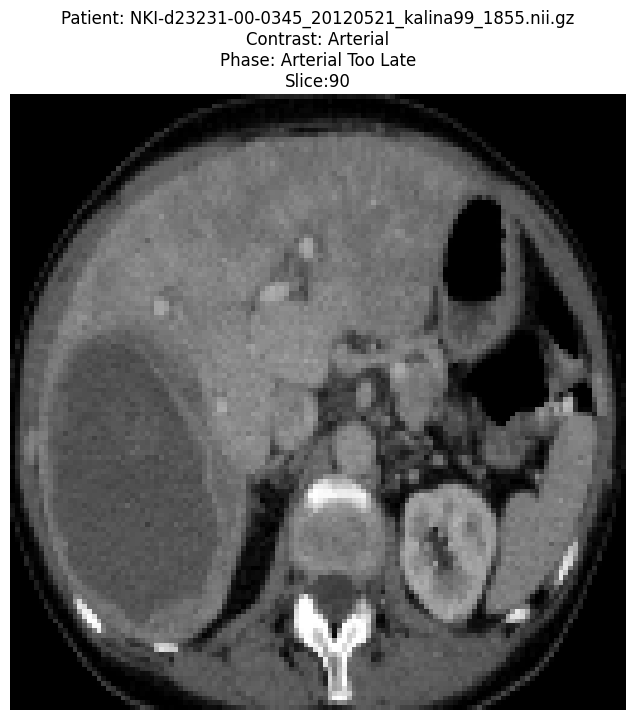

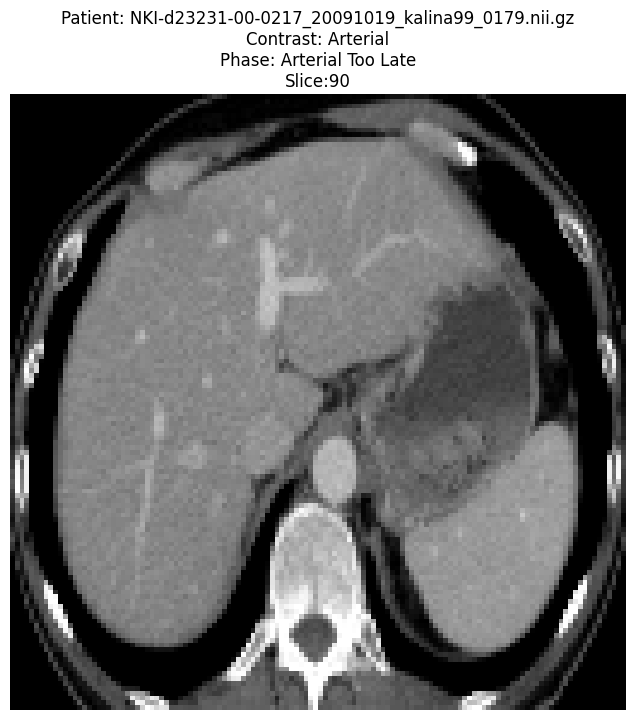

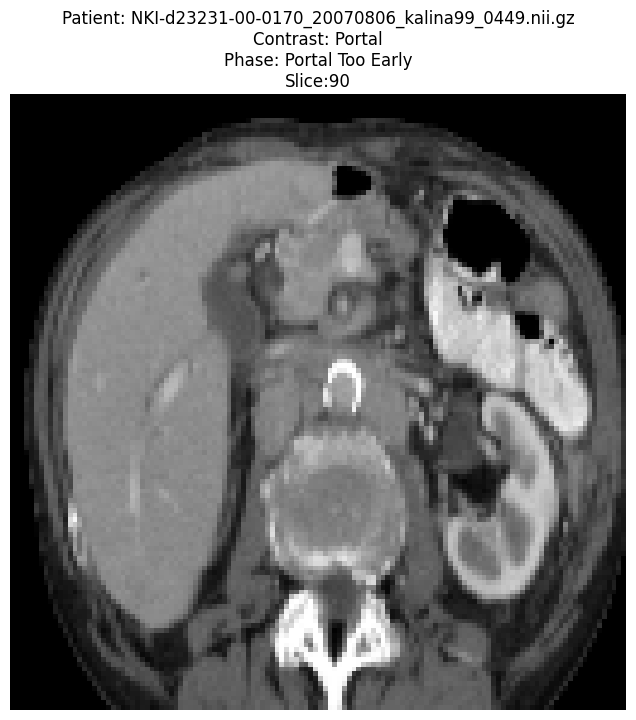

In [11]:
slice = 90
for i in range(len(with_lesions_images)):
    image = with_lesions_images[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {with_lesions_images[i][1]}\nContrast: {with_lesions_images[i][3]}\nPhase: {with_lesions_images[i][4]}\nSlice:{slice}")
    plt.axis("off")

In [11]:
partial_liver_images = show_misclass(folder, partial_liver["key"])

/tmp/ipykernel_578145/3868426600.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


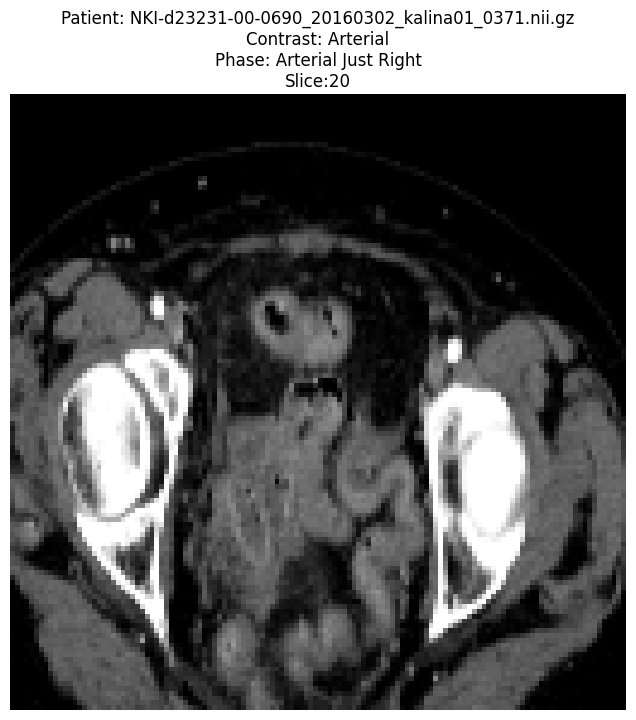

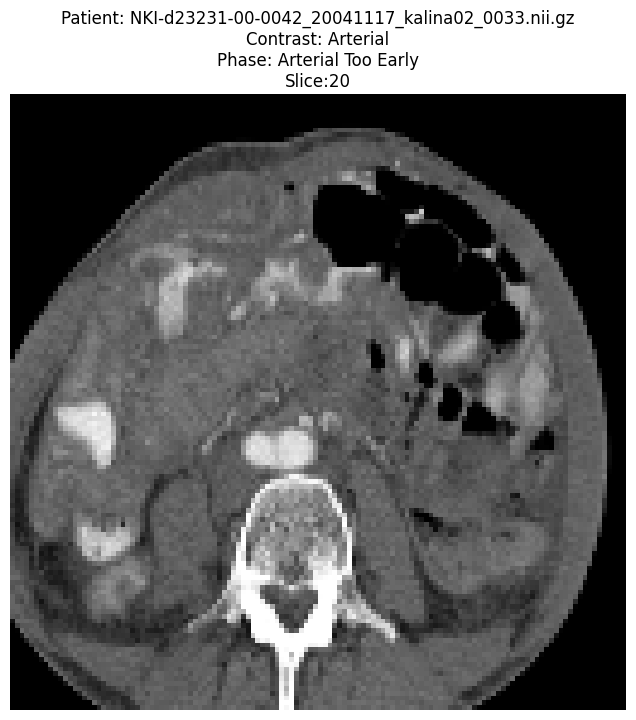

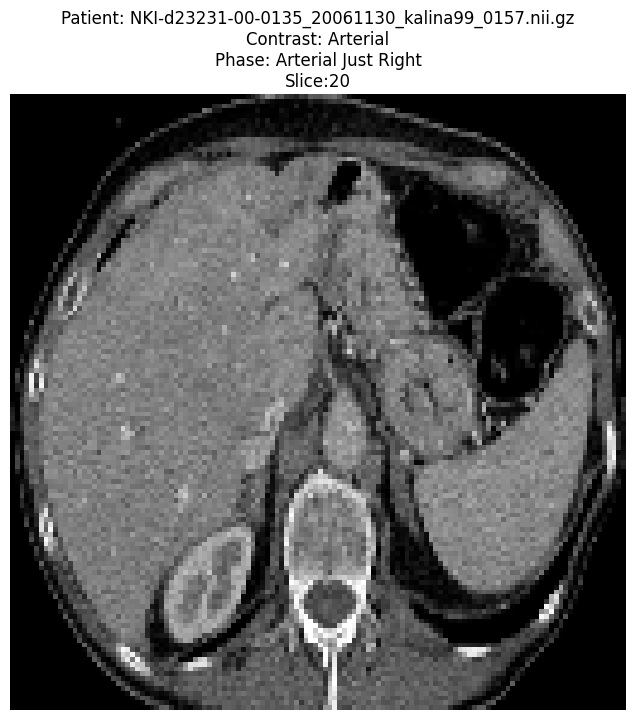

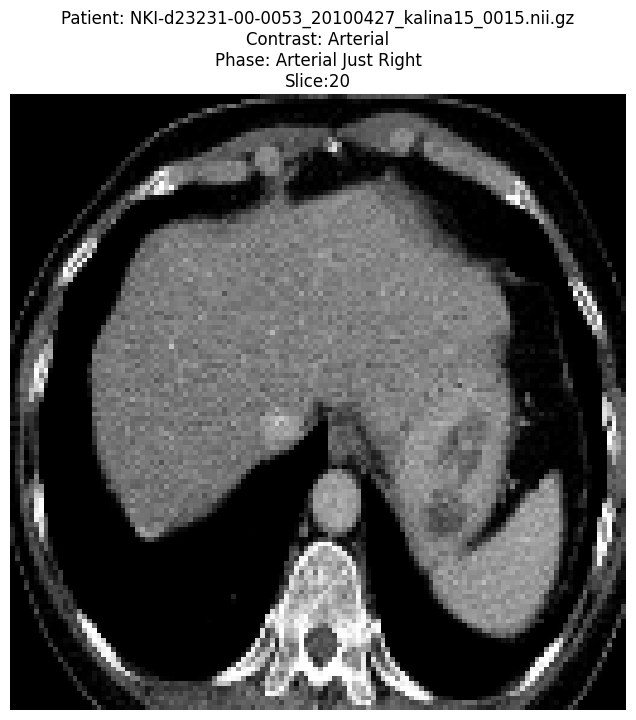

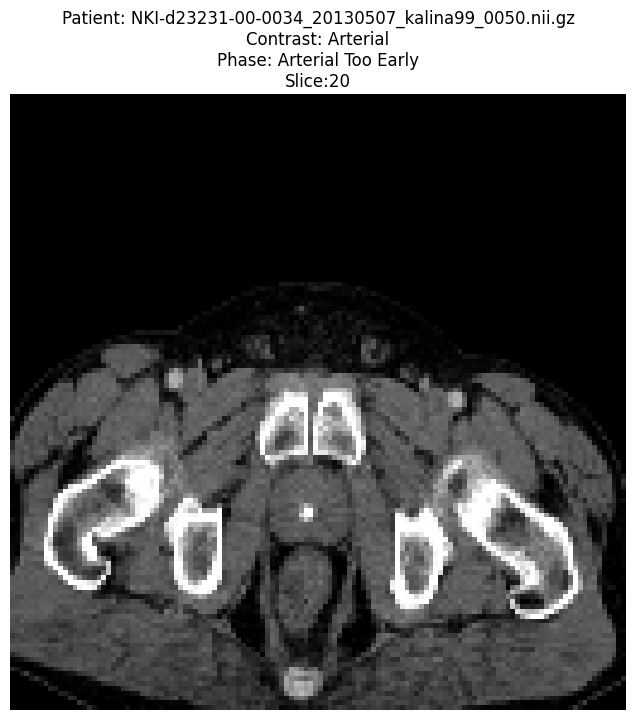

In [32]:
slice = 20
for i in range(min(5,len(partial_liver_images))):
    image = partial_liver_images[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {partial_liver_images[i][1]}\nContrast: {partial_liver_images[i][3]}\nPhase: {partial_liver_images[i][4]}\nSlice:{slice}")
    plt.axis("off")

In [29]:
not_abd_images = show_misclass(folder, not_abd["key"])

/tmp/ipykernel_402765/3868426600.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


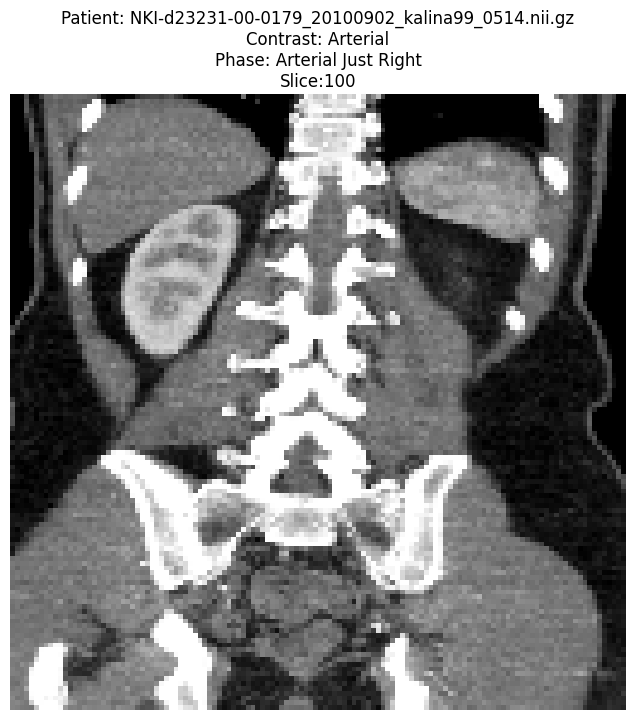

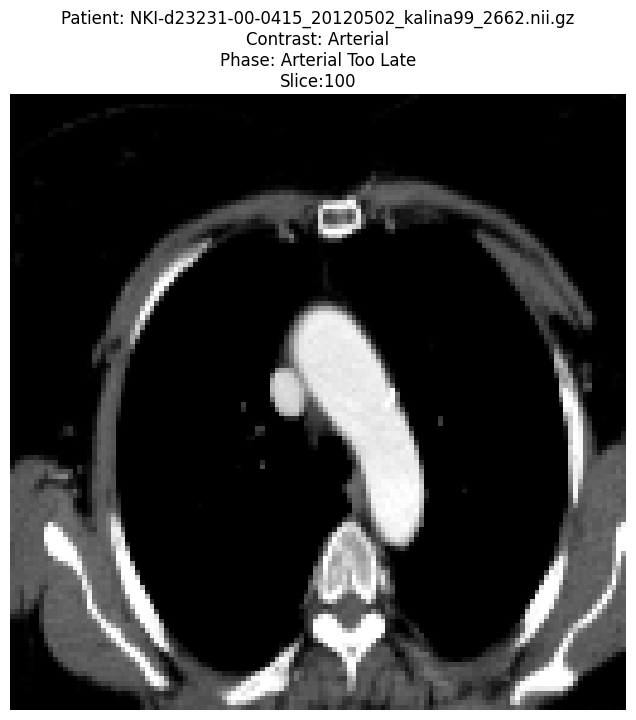

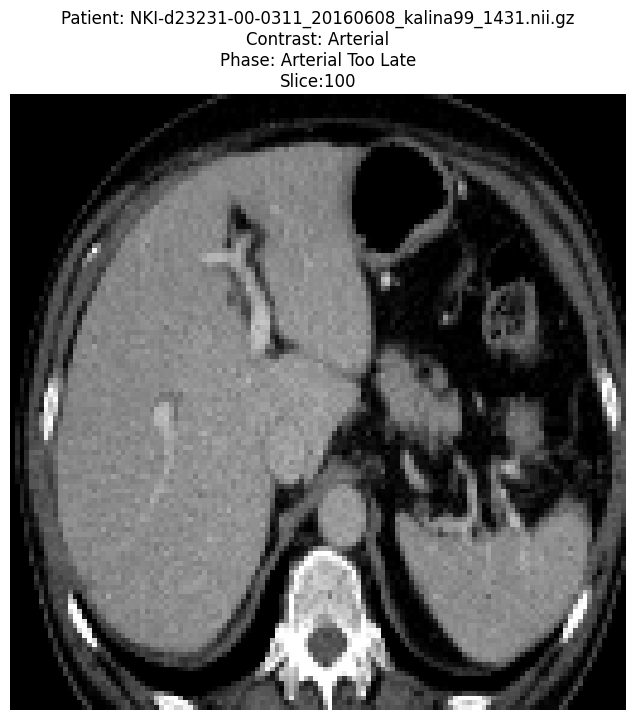

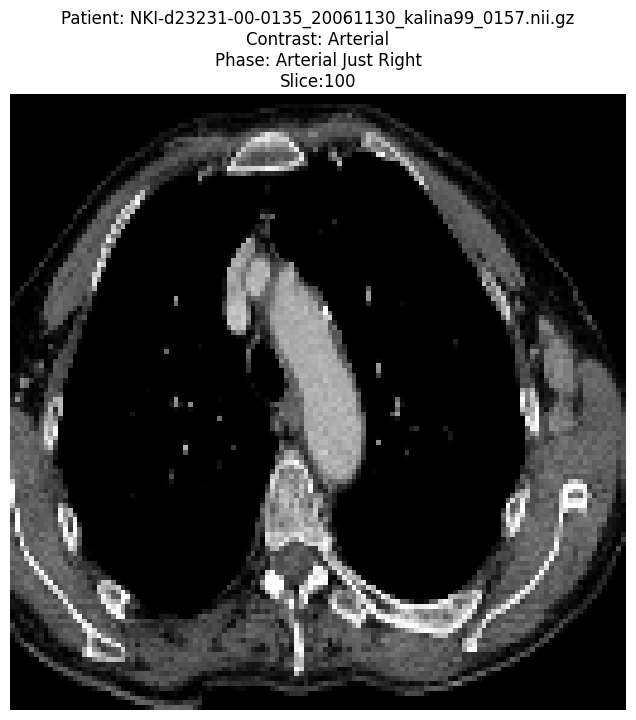

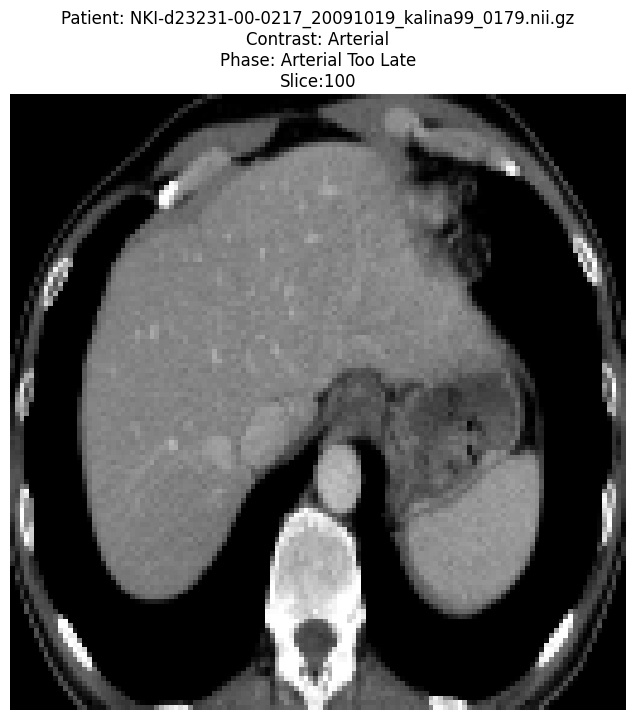

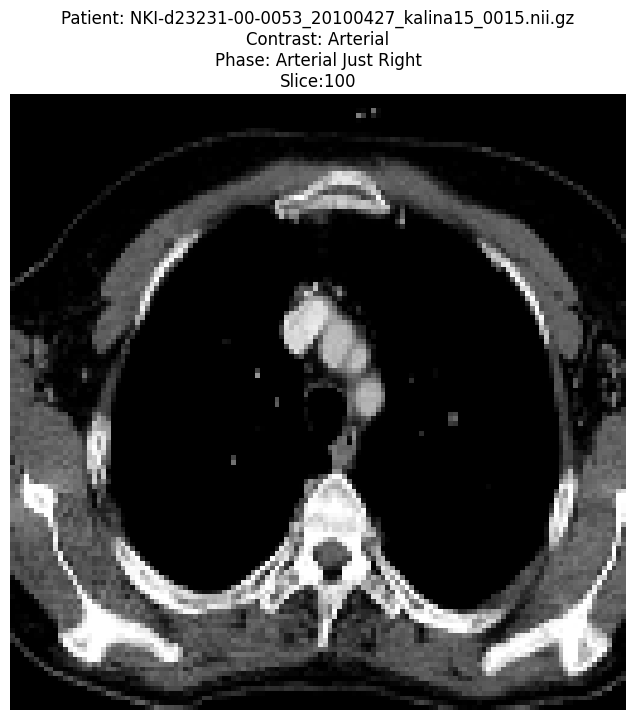

In [31]:
slice = 100
for i in range(len(not_abd_images)):
    image = not_abd_images[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {not_abd_images[i][1]}\nContrast: {not_abd_images[i][3]}\nPhase: {not_abd_images[i][4]}\nSlice:{slice}")
    plt.axis("off")